# Лабораторная работа №4
## Методы поиска условного экстремума

**Дисциплина:** Методы оптимизации

**Студент:** Пац И.Н.

**Группа:** ИУ5-23М

**Дата:** 03.05.2026

**Вариант:** 8 (a=2, b=158, x₀=2, n=2)

---

## Описание задания

**Цель работы:** Изучение алгоритмов условной оптимизации.

**Задачи:**
1. Реализовать метод штрафных функций (внешних штрафов).
2. Реализовать метод барьерных функций (внутренних штрафов).
3. Реализовать комбинированный метод штрафных и барьерных функций.
4. Реализовать метод модифицированных функций Лагранжа.
5. Реализовать метод проекции градиента.
6. Найти условный минимум тестовой функции Розенброка.
7. Сравнить точность и скорость сходимости различных методов.

**Тестовая функция:** Функция Розенброка

$$f(x) = \sum_{i=1}^{n-1} \left[ a (x_{i+1} - x_i^2)^2 + (1 - x_i)^2 \right]$$

**Параметры варианта 8:** a = 2, b = 158, x₀ = 2, n = 2

**Ограничения:**
- $g_1(x) = x_1^2 + x_2^2 - 10 \leq 0$
- $g_2(x) = x_2 - x_1 \leq 0$
- $g_3(x) = x_1 - x_2 \leq 0$

Из ограничений $g_2$ и $g_3$ следует $x_1 = x_2$. Тогда $g_1$ даёт $2x_1^2 \leq 10$, т.е. $|x_1| \leq \sqrt{5} \approx 2.236$.
Безусловный минимум функции Розенброка находится в точке $(1, 1)$, которая удовлетворяет всем ограничениям, следовательно, она же является точкой условного минимума.

---


---
## 1. Импорт библиотек и настройка окружения

Подключаем необходимые библиотеки: numpy для численных расчётов, matplotlib для визуализации, а также стандартные модули Python.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.patches import Circle
import time
import warnings
warnings.filterwarnings('ignore')

# Настройка отображения графиков
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
print('Библиотеки успешно загружены')

Библиотеки успешно загружены


---
## 2. Определение целевой функции и её градиента

Функция Розенброка для варианта 8: a = 2, b = 158, n = 2

$$f(x) = a (x_2 - x_1^2)^2 + (1 - x_1)^2$$

Градиент:
$$\frac{\partial f}{\partial x_1} = -4a x_1 (x_2 - x_1^2) - 2(1 - x_1)$$
$$\frac{\partial f}{\partial x_2} = 2a (x_2 - x_1^2)$$

In [2]:
# Параметры варианта 8
a = 2.0
b = 158.0
x0 = 2.0
n = 2

def rosenbrock(x):
    """Функция Розенброка."""
    x = np.asarray(x, dtype=float)
    result = 0.0
    for i in range(n - 1):
        result += a * (x[i+1] - x[i]**2)**2 + (1 - x[i])**2
    return result

def rosenbrock_grad(x):
    """Градиент функции Розенброка."""
    x = np.asarray(x, dtype=float)
    grad = np.zeros_like(x)
    for i in range(n - 1):
        grad[i] += -4.0 * a * x[i] * (x[i+1] - x[i]**2) - 2.0 * (1.0 - x[i])
        grad[i+1] += 2.0 * a * (x[i+1] - x[i]**2)
    return grad

# Проверка в точке (1, 1) - известный минимум
x_test = np.array([1.0, 1.0])
print(f'f(1, 1) = {rosenbrock(x_test):.6e}')
print(f'grad(1, 1) = {rosenbrock_grad(x_test)}')
print(f'f(2, 2) = {rosenbrock(np.array([2.0, 2.0])):.6f}')
print(f'f(0, 0) = {rosenbrock(np.array([0.0, 0.0])):.6f}')

f(1, 1) = 0.000000e+00
grad(1, 1) = [0. 0.]
f(2, 2) = 9.000000
f(0, 0) = 1.000000


---
## 3. Определение функций ограничений и их градиентов

Для варианта 8 заданы следующие ограничения:
- $g_1(x) = x_1^2 + x_2^2 - 10 \leq 0$
- $g_2(x) = x_2 - x_1 \leq 0$
- $g_3(x) = x_1 - x_2 \leq 0$

Из $g_2$ и $g_3$ следует $x_1 = x_2$. Допустимая область: $x_1 = x_2$ и $x_1^2 + x_2^2 \leq 10$.

In [3]:
# Функции ограничений
def g1(x):
    """g1(x) = x1^2 + x2^2 - 10 <= 0"""
    x = np.asarray(x, dtype=float)
    return x[0]**2 + x[1]**2 - 10.0

def g2(x):
    """g2(x) = x2 - x1 <= 0"""
    x = np.asarray(x, dtype=float)
    return x[1] - x[0]

def g3(x):
    """g3(x) = x1 - x2 <= 0"""
    x = np.asarray(x, dtype=float)
    return x[0] - x[1]

# Градиенты ограничений
def grad_g1(x):
    x = np.asarray(x, dtype=float)
    return np.array([2.0 * x[0], 2.0 * x[1]])

def grad_g2(x):
    return np.array([-1.0, 1.0])

def grad_g3(x):
    return np.array([1.0, -1.0])

# Список всех ограничений и их градиентов для удобства
constraints = [g1, g2, g3]
grad_constraints = [grad_g1, grad_g2, grad_g3]
constraint_names = ['g1', 'g2', 'g3']

# Проверка ограничений в точке (1, 1)
x_test = np.array([1.0, 1.0])
print('Проверка ограничений в точке (1, 1):')
for name, g in zip(constraint_names, constraints):
    val = g(x_test)
    status = '✓ выполнено' if val <= 0 else '✗ нарушено'
    print(f'  {name}(1, 1) = {val:.4f}  {status}')

# Проверка в недопустимой точке
x_bad = np.array([3.0, 3.0])
print('\nПроверка ограничений в точке (3, 3):')
for name, g in zip(constraint_names, constraints):
    val = g(x_bad)
    status = '✓ выполнено' if val <= 0 else '✗ нарушено'
    print(f'  {name}(3, 3) = {val:.4f}  {status}')

Проверка ограничений в точке (1, 1):
  g1(1, 1) = -8.0000  ✓ выполнено
  g2(1, 1) = 0.0000  ✓ выполнено
  g3(1, 1) = 0.0000  ✓ выполнено

Проверка ограничений в точке (3, 3):
  g1(3, 3) = 8.0000  ✗ нарушено
  g2(3, 3) = 0.0000  ✓ выполнено
  g3(3, 3) = 0.0000  ✓ выполнено


---
## 4. Визуализация функции Розенброка и допустимой области

Построим 3D-график функции Розенброка и отметим допустимую область (пересечение круга радиуса $\sqrt{10}$ и линии $x_1 = x_2$).

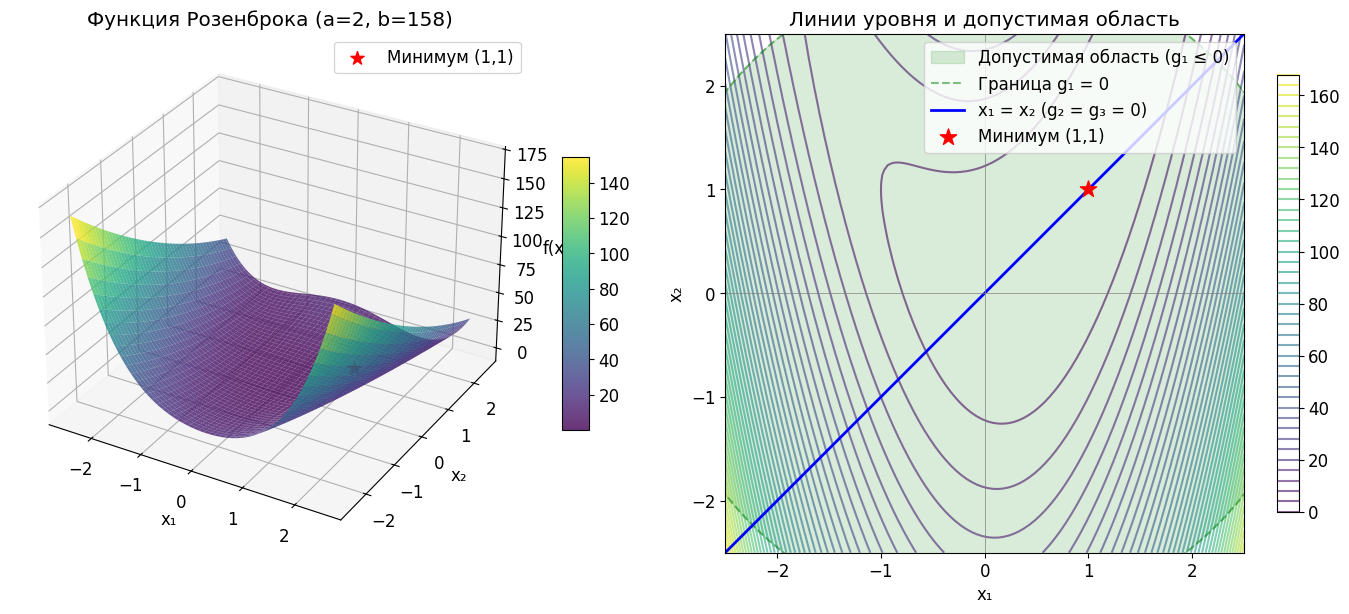

Визуализация завершена


In [4]:
# Создаём сетку для визуализации
x1_vals = np.linspace(-2.5, 2.5, 100)
x2_vals = np.linspace(-2.5, 2.5, 100)
X1, X2 = np.meshgrid(x1_vals, x2_vals)

# Вычисляем функцию Розенброка на сетке
Z = np.zeros_like(X1)
for i in range(len(x1_vals)):
    for j in range(len(x2_vals)):
        Z[j, i] = rosenbrock([X1[j, i], X2[j, i]])

# Ограничиваем значения для лучшей визуализации
Z_plot = np.clip(Z, 0, 500)

fig = plt.figure(figsize=(14, 6))

# 3D-график
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf = ax1.plot_surface(X1, X2, Z_plot, cmap='viridis', alpha=0.8, linewidth=0)
ax1.set_xlabel('x₁')
ax1.set_ylabel('x₂')
ax1.set_zlabel('f(x)')
ax1.set_title('Функция Розенброка (a=2, b=158)')
fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=10)

# Отметим точку минимума
ax1.scatter(1, 1, rosenbrock([1, 1]), color='red', s=100, marker='*', label='Минимум (1,1)')
ax1.legend()

# 2D-график с допустимой областью
ax2 = fig.add_subplot(1, 2, 2)
contour = ax2.contour(X1, X2, Z_plot, levels=50, cmap='viridis', alpha=0.6)
ax2.set_xlabel('x₁')
ax2.set_ylabel('x₂')
ax2.set_title('Линии уровня и допустимая область')
plt.colorbar(contour, ax=ax2, shrink=0.8)

# Допустимая область: круг радиуса sqrt(10)
theta = np.linspace(0, 2*np.pi, 100)
circle_x = np.sqrt(10) * np.cos(theta)
circle_y = np.sqrt(10) * np.sin(theta)
ax2.fill(circle_x, circle_y, alpha=0.15, color='green', label='Допустимая область (g₁ ≤ 0)')
ax2.plot(circle_x, circle_y, 'g--', alpha=0.5, label='Граница g₁ = 0')

# Линия x1 = x2 (из g2 и g3)
line_x = np.linspace(-2.5, 2.5, 100)
line_y = line_x
ax2.plot(line_x, line_y, 'b-', linewidth=2, label='x₁ = x₂ (g₂ = g₃ = 0)')

# Точка минимума
ax2.scatter(1, 1, color='red', s=150, marker='*', zorder=5, label='Минимум (1,1)')
ax2.axhline(0, color='gray', linewidth=0.5)
ax2.axvline(0, color='gray', linewidth=0.5)
ax2.set_xlim(-2.5, 2.5)
ax2.set_ylim(-2.5, 2.5)
ax2.set_aspect('equal')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()
print('Визуализация завершена')

---
## 5. Метод штрафных функций (внешних штрафов)

### Стратегия поиска

Идея метода заключается в сведении задачи условной оптимизации к последовательности задач безусловной минимизации вспомогательной функции:

$$F(x, r_k) = f(x) + P(x, r_k)$$

где $P(x, r_k)$ — штрафная функция, $r_k$ — параметр штрафа.

Для ограничений типа неравенств используется квадрат срезки:

$$P(x, r_k) = \frac{r_k}{2} \sum_{j=1}^{m} \left[ g_j^+(x) \right]^2$$

где $g_j^+(x) = \max(0, g_j(x))$ — срезка функции.

### Алгоритм

1. Задать начальную точку $x_0$ (обычно вне допустимой области), начальное значение $r_0 > 0$, множитель увеличения $C > 1$, точность $\varepsilon > 0$. $k = 0$.
2. Составить вспомогательную функцию $F(x, r_k) = f(x) + P(x, r_k)$.
3. Найти точку $x^*(r_k)$ безусловного минимума $F(x, r_k)$ по $x$.
4. Если $P(x^*(r_k), r_k) \leq \varepsilon$, то останов: $x^* \approx x^*(r_k)$.
5. Иначе: $r_{k+1} = C \cdot r_k$, $x_{k+1} = x^*(r_k)$, $k = k+1$, перейти к шагу 2.

### Реализация

В качестве метода безусловной минимизации используем BFGS (из лабораторной работы №3).

In [5]:
# ---------- Метод штрафных функций (внешних штрафов) ----------

def bfgs_optimize(f, grad_f, x0, max_iter=1000, tol=1e-8):
    """
    BFGS метод безусловной минимизации.
    
    Parameters:
    - f: целевая функция
    - grad_f: градиент целевой функции
    - x0: начальная точка
    - max_iter: максимальное число итераций
    - tol: tolerance для остановки
    
    Returns:
    - (x_opt, f_opt, history)
    """
    x = np.asarray(x0, dtype=float).copy()
    n = len(x)
    H = np.eye(n)  # начальная аппроксимация гессиана
    
    history = {'x': [x.copy()], 'f': [f(x)], 'grad_norm': [np.linalg.norm(grad_f(x))]}
    
    grad = grad_f(x)
    
    for k in range(max_iter):
        if np.linalg.norm(grad) < tol:
            break
        
        # Направление поиска
        p = -H @ grad
        
        # Золотое сечение для выбора шага
        phi = (np.sqrt(5) - 1) / 2
        a, b = 0.0, 1.0
        x1 = a + (1 - phi) * (b - a)
        x2 = a + phi * (b - a)
        
        f1 = f(x + x1 * p)
        f2 = f(x + x2 * p)
        
        for _ in range(30):
            if abs(b - a) < 1e-8:
                break
            if f1 < f2:
                b = x2
                x2 = x1
                f2 = f1
                x1 = a + (1 - phi) * (b - a)
                f1 = f(x + x1 * p)
            else:
                a = x1
                x1 = x2
                f1 = f2
                x2 = a + phi * (b - a)
                f2 = f(x + x2 * p)
        
        alpha = (a + b) / 2
        
        # Шаг
        s = alpha * p
        x_new = x + s
        grad_new = grad_f(x_new)
        
        # Разность градиентов
        y = grad_new - grad
        
        # Обновление H (BFGS)
        sy = s @ y
        if sy > 1e-10:
            H = H + (sy + y @ H @ y) * np.outer(s, s) / (sy**2) - \
                 (np.outer(H @ y, s) + np.outer(s, H @ y)) / sy
        
        x = x_new
        grad = grad_new
        
        history['x'].append(x.copy())
        history['f'].append(f(x))
        history['grad_norm'].append(np.linalg.norm(grad))
    
    return x, f(x), history


def penalty_function(x, r):
    """
    Штрафная функция (внешний штраф).
    P(x, r) = (r/2) * sum(max(0, g_j(x))^2)
    """
    penalty = 0.0
    for g in constraints:
        val = g(x)
        if val > 0:
            penalty += val**2
    return 0.5 * r * penalty


def penalty_gradient(x, r):
    """
    Градиент штрафной функции.
    """
    grad = np.zeros_like(x, dtype=float)
    for g, grad_g in zip(constraints, grad_constraints):
        val = g(x)
        if val > 0:
            grad += val * grad_g(x)
    return r * grad


def augmented_function(x, r):
    """Вспомогательная функция F(x, r) = f(x) + P(x, r)."""
    return rosenbrock(x) + penalty_function(x, r)


def augmented_gradient(x, r):
    """Градиент вспомогательной функции."""
    return rosenbrock_grad(x) + penalty_gradient(x, r)


def penalty_method(x0, r0=1.0, C=10.0, epsilon=1e-6, max_outer=50):
    """
    Метод штрафных функций (внешних штрафов).
    
    Parameters:
    - x0: начальная точка
    - r0: начальное значение параметра штрафа
    - C: множитель увеличения параметра штрафа
    - epsilon: точность остановки
    - max_outer: максимальное число внешних итераций
    
    Returns:
    - (x_opt, f_opt, history)
    """
    x = np.asarray(x0, dtype=float).copy()
    r = r0
    
    history = {
        'x': [],
        'f': [],
        'r': [],
        'penalty': [],
        'g1': [], 'g2': [], 'g3': [],
        'outer_iter': []
    }
    
    print(f"{'k':<5} {'r_k':<12} {'x1':<12} {'x2':<12} {'f(x)':<14} {'P(x,r)':<14} {'||grad||':<12}")
    print('-' * 80)
    
    for outer_k in range(max_outer):
        # Создаём функции с фиксированным r
        def F(x):
            return augmented_function(x, r)
        def grad_F(x):
            return augmented_gradient(x, r)
        
        # Безусловная минимизация BFGS
        x_opt, f_opt, inner_history = bfgs_optimize(F, grad_F, x, tol=1e-8)
        
        pen_val = penalty_function(x_opt, 1.0)  # без r, только сумма квадратов
        pen_val_full = penalty_function(x_opt, r)  # полный штраф
        
        # Сохраняем историю
        history['x'].append(x_opt.copy())
        history['f'].append(f_opt)
        history['r'].append(r)
        history['penalty'].append(pen_val)
        history['g1'].append(g1(x_opt))
        history['g2'].append(g2(x_opt))
        history['g3'].append(g3(x_opt))
        history['outer_iter'].append(outer_k)
        
        grad_norm = np.linalg.norm(grad_F(x_opt))
        
        print(f"{outer_k:<5} {r:<12.6f} {x_opt[0]:<12.8f} {x_opt[1]:<12.8f} "
              f"{f_opt:<14.8e} {pen_val_full:<14.8e} {grad_norm:<12.8e}")
        
        # Проверка условия остановки
        if pen_val < epsilon:
            print(f"\nМетод сошёлся за {outer_k + 1} внешних итераций.")
            break
        
        # Увеличиваем параметр штрафа
        r *= C
        x = x_opt.copy()
    else:
        print(f"\nМетод не сошёлся за {max_outer} итераций.")
    
    return x_opt, f_opt, history

In [6]:
# Запуск метода штрафных функций
# Начальная точка вне допустимой области
x0_penalty = np.array([3.0, 3.0])

print("=" * 80)
print("МЕТОД ШТРАФНЫХ ФУНКЦИЙ (ВНЕШНИХ ШТРАФОВ)")
print("=" * 80)
print(f"Начальная точка: x0 = {x0_penalty}")
print(f"Параметры: r0 = 1.0, C = 10.0, epsilon = 1e-6")
print()

start_time = time.time()
x_penalty, f_penalty, hist_penalty = penalty_method(x0_penalty)
elapsed = time.time() - start_time

print()
print(f"Результат метода штрафных функций:")
print(f"  x* = ({x_penalty[0]:.10f}, {x_penalty[1]:.10f})")
print(f"  f(x*) = {f_penalty:.12e}")
print(f"  Время выполнения: {elapsed:.4f} с")
print(f"  Число внешних итераций: {len(hist_penalty['outer_iter'])}")
print()
print("Проверка ограничений:")
for name, g in zip(constraint_names, constraints):
    val = g(x_penalty)
    status = '✓' if val <= 0 else '✗'
    print(f"  {name}(x*) = {val:.8e} {status}")

МЕТОД ШТРАФНЫХ ФУНКЦИЙ (ВНЕШНИХ ШТРАФОВ)
Начальная точка: x0 = [3. 3.]
Параметры: r0 = 1.0, C = 10.0, epsilon = 1e-6

k     r_k          x1           x2           f(x)           P(x,r)         ||grad||    
--------------------------------------------------------------------------------
0     1.000000     1.00000000   1.00000000   5.03554424e-20 1.62701825e-20 1.26131580e-09

Метод сошёлся за 1 внешних итераций.

Результат метода штрафных функций:
  x* = (0.9999999999, 0.9999999998)
  f(x*) = 5.035544243150e-20
  Время выполнения: 0.0032 с
  Число внешних итераций: 1

Проверка ограничений:
  g1(x*) = -8.00000000e+00 ✓
  g2(x*) = -1.80389481e-10 ✓
  g3(x*) = 1.80389481e-10 ✗


---
### Визуализация сходимости метода штрафных функций

Покажем траекторию поиска и значения штрафной функции на каждой итерации.

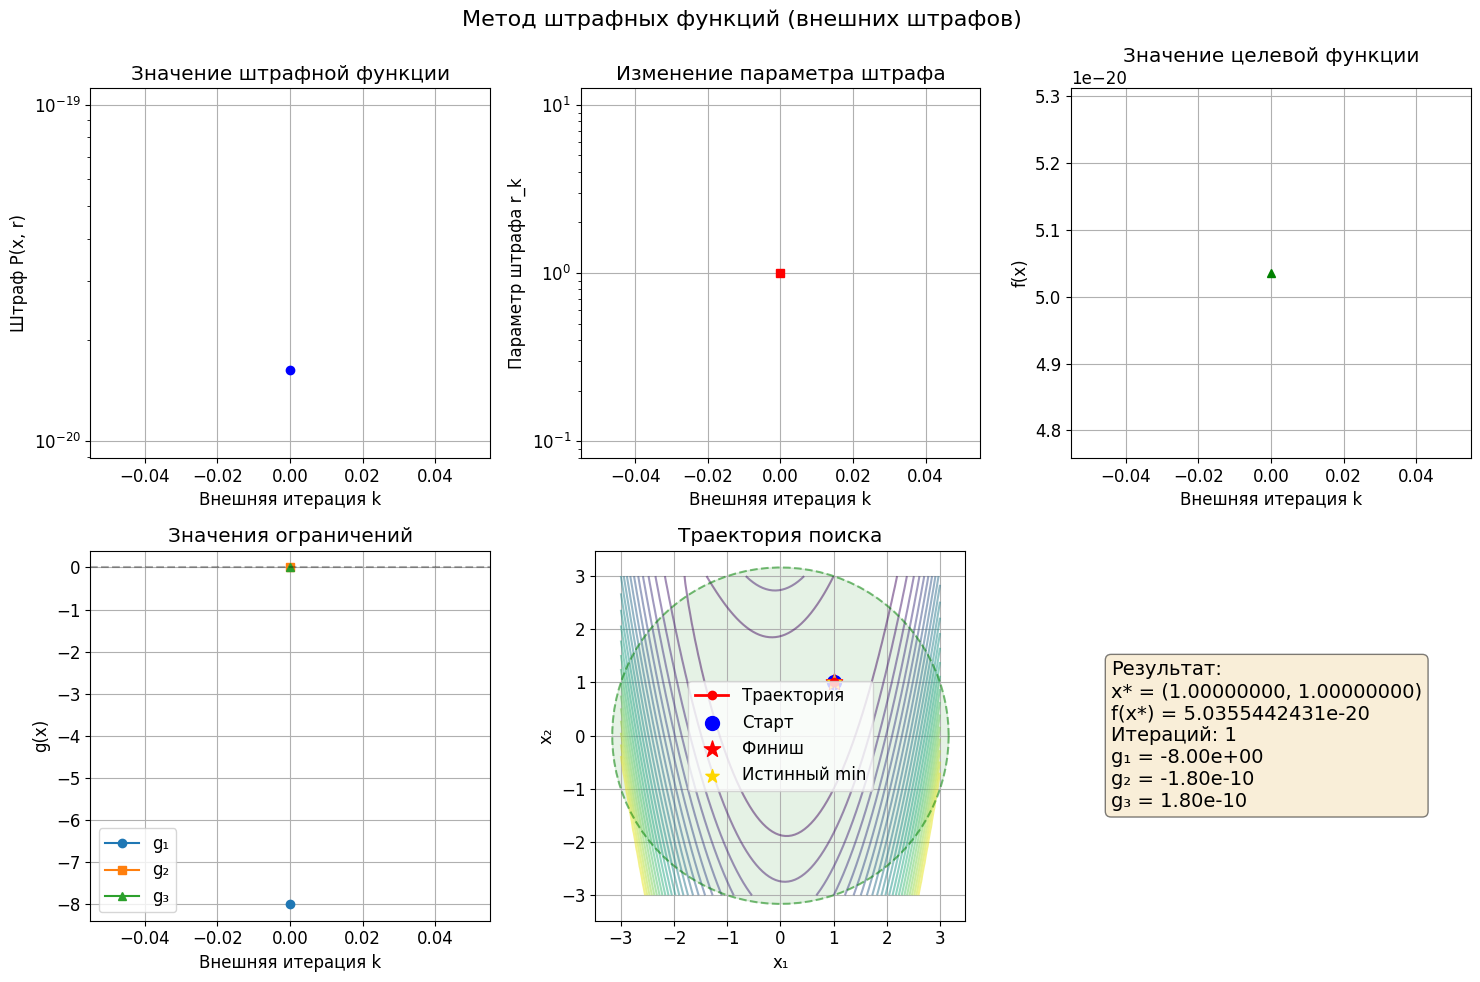

In [7]:
# Визуализация сходимости метода штрафных функций
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

ax1 = axes[0, 0]
ax1.semilogy(hist_penalty['outer_iter'], hist_penalty['penalty'], 'bo-', markersize=6)
ax1.set_xlabel('Внешняя итерация k')
ax1.set_ylabel('Штраф P(x, r)')
ax1.set_title('Значение штрафной функции')
ax1.grid(True)

ax2 = axes[0, 1]
ax2.semilogy(hist_penalty['outer_iter'], hist_penalty['r'], 'rs-', markersize=6)
ax2.set_xlabel('Внешняя итерация k')
ax2.set_ylabel('Параметр штрафа r_k')
ax2.set_title('Изменение параметра штрафа')
ax2.grid(True)

ax3 = axes[0, 2]
ax3.plot(hist_penalty['outer_iter'], hist_penalty['f'], 'g^-', markersize=6)
ax3.set_xlabel('Внешняя итерация k')
ax3.set_ylabel('f(x)')
ax3.set_title('Значение целевой функции')
ax3.grid(True)

ax4 = axes[1, 0]
ax4.plot(hist_penalty['outer_iter'], hist_penalty['g1'], 'o-', label='g₁', markersize=6)
ax4.plot(hist_penalty['outer_iter'], hist_penalty['g2'], 's-', label='g₂', markersize=6)
ax4.plot(hist_penalty['outer_iter'], hist_penalty['g3'], '^-', label='g₃', markersize=6)
ax4.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax4.set_xlabel('Внешняя итерация k')
ax4.set_ylabel('g(x)')
ax4.set_title('Значения ограничений')
ax4.legend()
ax4.grid(True)

# Траектория на 2D-графике
ax5 = axes[1, 1]
x1_vals = np.linspace(-3, 3, 100)
x2_vals = np.linspace(-3, 3, 100)
X1, X2 = np.meshgrid(x1_vals, x2_vals)
Z = np.zeros_like(X1)
for i in range(len(x1_vals)):
    for j in range(len(x2_vals)):
        Z[j, i] = rosenbrock([X1[j, i], X2[j, i]])
Z_plot = np.clip(Z, 0, 200)
ax5.contour(X1, X2, Z_plot, levels=30, cmap='viridis', alpha=0.5)

# Допустимая область
theta = np.linspace(0, 2*np.pi, 100)
circle_x = np.sqrt(10) * np.cos(theta)
circle_y = np.sqrt(10) * np.sin(theta)
ax5.fill(circle_x, circle_y, alpha=0.1, color='green')
ax5.plot(circle_x, circle_y, 'g--', alpha=0.5)

# Траектория
traj_x = [pt[0] for pt in hist_penalty['x']]
traj_y = [pt[1] for pt in hist_penalty['x']]
ax5.plot(traj_x, traj_y, 'r-o', markersize=6, linewidth=2, label='Траектория')
ax5.scatter(traj_x[0], traj_y[0], color='blue', s=100, marker='o', label='Старт')
ax5.scatter(traj_x[-1], traj_y[-1], color='red', s=150, marker='*', label='Финиш')
ax5.scatter(1, 1, color='gold', s=100, marker='*', label='Истинный min')
ax5.set_xlabel('x₁')
ax5.set_ylabel('x₂')
ax5.set_title('Траектория поиска')
ax5.set_aspect('equal')
ax5.legend()
ax5.grid(True)

# Информация о результате
ax6 = axes[1, 2]
ax6.axis('off')
info_text = (
    f"Результат:\n"
    f"x* = ({x_penalty[0]:.8f}, {x_penalty[1]:.8f})\n"
    f"f(x*) = {f_penalty:.10e}\n"
    f"Итераций: {len(hist_penalty['outer_iter'])}\n"
    f"g₁ = {g1(x_penalty):.2e}\n"
    f"g₂ = {g2(x_penalty):.2e}\n"
    f"g₃ = {g3(x_penalty):.2e}"
)
ax6.text(0.1, 0.5, info_text, fontsize=14, verticalalignment='center',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Метод штрафных функций (внешних штрафов)', fontsize=16)
plt.tight_layout()
plt.show()

---
## 6. Метод барьерных функций (внутренних штрафов)

### Стратегия поиска

Идея метода заключается в добавлении к целевой функции барьерной функции, которая препятствует выходу точек за пределы допустимой области:

$$F(x, r_k) = f(x) + P(x, r_k)$$

где $P(x, r_k)$ — барьерная функция, $r_k$ — параметр штрафа.

Используется обратная барьерная функция:

$$P(x, r_k) = -r_k \sum_{j=1}^{m} \frac{1}{g_j(x)}$$

или логарифмическая:

$$P(x, r_k) = -r_k \sum_{j=1}^{m} \ln(-g_j(x))$$

### Алгоритм

1. Задать начальную точку $x_0$ **внутри** допустимой области, начальное значение $r_0 > 0$, множитель уменьшения $C > 1$, точность $\varepsilon > 0$. $k = 0$.
2. Составить вспомогательную функцию $F(x, r_k) = f(x) + P(x, r_k)$.
3. Найти точку $x^*(r_k)$ безусловного минимума $F(x, r_k)$ по $x$ с проверкой принадлежности внутренности множества.
4. Если $P(x^*(r_k), r_k) \leq \varepsilon$, то останов: $x^* \approx x^*(r_k)$.
5. Иначе: $r_{k+1} = r_k / C$, $x_{k+1} = x^*(r_k)$, $k = k+1$, перейти к шагу 2.

### Реализация

Используем обратную барьерную функцию. В качестве метода безусловной минимизации используем BFGS.

In [8]:
# ---------- Метод барьерных функций (внутренних штрафов) ----------
# ВНИМАНИЕ: Ограничения g2 и g3 вместе означают x1 = x2.
# Допустимая область не имеет внутренности (это линия x1=x2).
# Поэтому барьер применяется только к g1 (круг), а g2/g3 учитываются
# через штраф (x1 - x2)^2, чтобы обеспечить выполнение x1 = x2.

def is_feasible(x):
    """Проверка принадлежности точки внутренности допустимой области.
    
    Для барьерного метода проверяем только g1 (круг), так как
    g2 и g3 вместе задают линию x1=x2 без внутренности.
    """
    if g1(x) >= -1e-12:  # строго внутри круга (g1(x) < 0)
        return False
    return True


def barrier_function_inverse(x, r):
    """
    Обратная барьерная функция.
    Применяется только к g1 (круговое ограничение).
    Для g2/g3 используем штраф (x1 - x2)^2.
    P(x, r) = -r / g1(x) + (x1 - x2)^2
    """
    val = g1(x)
    if val >= 0:
        return np.inf  # недопустимая точка
    # Барьер для g1 + штраф за нарушение x1 = x2
    return r / (-val) + (x[0] - x[1])**2


def barrier_gradient_inverse(x, r):
    """
    Градиент обратной барьерной функции.
    """
    val = g1(x)
    if val >= 0:
        return np.full_like(x, np.inf)
    # Градиент: r / g1^2 * grad(g1) + 2*(x1-x2)*[1, -1]
    grad = r * grad_g1(x) / (val**2)
    grad += 2.0 * (x[0] - x[1]) * np.array([1.0, -1.0])
    return grad


def barrier_function_log(x, r):
    """
    Логарифмическая барьерная функция.
    Применяется только к g1 (круговое ограничение).
    P(x, r) = -r * ln(-g1(x)) + (x1 - x2)^2
    """
    val = g1(x)
    if val >= 0:
        return np.inf
    return -r * np.log(-val) + (x[0] - x[1])**2


def barrier_gradient_log(x, r):
    """
    Градиент логарифмической барьерной функции.
    """
    val = g1(x)
    if val >= 0:
        return np.full_like(x, np.inf)
    # Градиент: -r / g1 * grad(g1) + 2*(x1-x2)*[1, -1]
    grad = -r * grad_g1(x) / val
    grad += 2.0 * (x[0] - x[1]) * np.array([1.0, -1.0])
    return grad


def barrier_method(x0, r0=1.0, C=10.0, epsilon=1e-6, max_outer=50, use_log=False):
    """
    Метод барьерных функций (внутренних штрафов).
    
    Parameters:
    - x0: начальная точка (должна быть внутри допустимой области)
    - r0: начальное значение параметра штрафа
    - C: множитель уменьшения параметра штрафа (r_{k+1} = r_k / C)
    - epsilon: точность остановки по величине барьерного члена
    - max_outer: максимальное число внешних итераций
    - use_log: использовать логарифмическую (True) или обратную (False) барьерную функцию
    
    Returns:
    - (x_opt, f_opt, history)
    """
    x = np.asarray(x0, dtype=float).copy()
    r = r0
    
    if not is_feasible(x):
        print("ОШИБКА: Начальная точка должна быть внутри допустимой области!")
        return x, rosenbrock(x), None
    
    if use_log:
        barrier_func = barrier_function_log
        barrier_grad_func = barrier_gradient_log
        barrier_name = "логарифмической"
    else:
        barrier_func = barrier_function_inverse
        barrier_grad_func = barrier_gradient_inverse
        barrier_name = "обратной"
    
    history = {
        'x': [],
        'f': [],
        'r': [],
        'penalty': [],
        'g1': [], 'g2': [], 'g3': [],
        'outer_iter': []
    }
    
    print(f"Метод барьерных функций ({barrier_name})")
    print(f"{'k':<5} {'r_k':<12} {'x1':<12} {'x2':<12} {'f(x)':<14} {'P(x,r)':<14} {'||grad||':<12}")
    print('-' * 80)
    
    for outer_k in range(max_outer):
        # Создаём функции с фиксированным r
        def F(x):
            return rosenbrock(x) + barrier_func(x, r)
        def grad_F(x):
            g = barrier_grad_func(x, r)
            if np.any(np.isinf(g)):
                return g
            return rosenbrock_grad(x) + g
        
        # Безусловная минимизация BFGS с проверкой допустимости
        x_opt, f_opt, inner_history = bfgs_optimize(F, grad_F, x, tol=1e-8)
        
        pen_val_full = barrier_func(x_opt, r)  # полный штраф
        
        if np.isinf(pen_val_full):
            print(f"{outer_k:<5} {r:<12.6f} - точка вне допустимой области - останов")
            break
        
        # Сохраняем историю
        history['x'].append(x_opt.copy())
        history['f'].append(f_opt)
        history['r'].append(r)
        history['penalty'].append(pen_val_full)
        history['g1'].append(g1(x_opt))
        history['g2'].append(g2(x_opt))
        history['g3'].append(g3(x_opt))
        history['outer_iter'].append(outer_k)
        
        grad_norm = np.linalg.norm(grad_F(x_opt))
        
        print(f"{outer_k:<5} {r:<12.6f} {x_opt[0]:<12.8f} {x_opt[1]:<12.8f} "
              f"{f_opt:<14.8e} {pen_val_full:<14.8e} {grad_norm:<12.8e}")
        
        # Проверка условия остановки: |барьерный член| < epsilon
        # Для обратной: r/(-g1) -> 0 при r -> 0
        # Для логарифмической: -r*ln(-g1) -> 0 при r -> 0
        if abs(pen_val_full) < epsilon:
            print(f"\nМетод сошёлся за {outer_k + 1} внешних итераций.")
            break
        
        # Уменьшаем параметр штрафа
        r /= C
        x = x_opt.copy()
    else:
        print(f"\nМетод не сошёлся за {max_outer} итераций.")
    
    return x_opt, f_opt, history

In [9]:
# Запуск метода барьерных функций
# Начальная точка строго внутри круга (g1 < 0) и на линии x1 = x2
x0_barrier = np.array([0.5, 0.5])

print("=" * 80)
print("МЕТОД БАРЬЕРНЫХ ФУНКЦИЙ (ВНУТРЕННИХ ШТРАФОВ)")
print("=" * 80)
print(f"Начальная точка: x0 = {x0_barrier}")
print(f"Параметры: r0 = 1.0, C = 10.0, epsilon = 1e-6")
print(f"Проверка допустимости: is_feasible(x0) = {is_feasible(x0_barrier)}")
print()

# Используем обратную барьерную функцию
start_time = time.time()
x_barrier, f_barrier, hist_barrier = barrier_method(
    x0_barrier, r0=1.0, C=10.0, epsilon=1e-6, use_log=False
)
elapsed = time.time() - start_time

print()
print(f"Результат метода барьерных функций (обратная):")
print(f"  x* = ({x_barrier[0]:.10f}, {x_barrier[1]:.10f})")
print(f"  f(x*) = {f_barrier:.12e}")
print(f"  Время выполнения: {elapsed:.4f} с")
if hist_barrier:
    print(f"  Число внешних итераций: {len(hist_barrier['outer_iter'])}")
print()
print("Проверка ограничений:")
for name, g in zip(constraint_names, constraints):
    val = g(x_barrier)
    status = 'V' if val <= 0 else 'X'
    print(f"  {name}(x*) = {val:.8e} {status}")

МЕТОД БАРЬЕРНЫХ ФУНКЦИЙ (ВНУТРЕННИХ ШТРАФОВ)
Начальная точка: x0 = [0.5 0.5]
Параметры: r0 = 1.0, C = 10.0, epsilon = 1e-6
Проверка допустимости: is_feasible(x0) = True

Метод барьерных функций (обратной)
k     r_k          x1           x2           f(x)           P(x,r)         ||grad||    
--------------------------------------------------------------------------------
0     1.000000     0.97629980   0.95605597   1.23947218e-01 1.23368761e-01 9.86409271e-09
1     0.100000     0.99751413   0.99534444   1.24888455e-02 1.24824738e-02 4.65701627e-09
2     0.010000     0.99975014   0.99953157   1.24988777e-03 1.24982339e-03 1.48566612e-09
3     0.001000     0.99997500   0.99995313   1.24998877e-04 1.24998233e-04 8.65908332e-12
4     0.000100     0.99999750   0.99999531   1.24999888e-05 1.24999823e-05 1.24562337e-09
5     0.000010     0.99999975   0.99999952   1.24999989e-06 1.24999982e-06 8.83201618e-09
6     0.000001     0.99999997   0.99999994   1.24999999e-07 1.24999998e-07 9.69526584e

In [10]:
# Запуск с логарифмической барьерной функцией
print("=" * 80)
print("МЕТОД БАРЬЕРНЫХ ФУНКЦИЙ (ЛОГАРИФМИЧЕСКАЯ)")
print("=" * 80)
print()

start_time = time.time()
x_barrier_log, f_barrier_log, hist_barrier_log = barrier_method(
    x0_barrier, r0=1.0, C=10.0, epsilon=1e-6, use_log=True
)
elapsed = time.time() - start_time

print()
print(f"Результат метода барьерных функций (логарифмическая):")
print(f"  x* = ({x_barrier_log[0]:.10f}, {x_barrier_log[1]:.10f})")
print(f"  f(x*) = {f_barrier_log:.12e}")
print(f"  Время выполнения: {elapsed:.4f} с")
if hist_barrier_log:
    print(f"  Число внешних итераций: {len(hist_barrier_log['outer_iter'])}")
print()
print("Проверка ограничений:")
for name, g in zip(constraint_names, constraints):
    val = g(x_barrier_log)
    status = 'V' if val <= 0 else 'X'
    print(f"  {name}(x*) = {val:.8e} {status}")

МЕТОД БАРЬЕРНЫХ ФУНКЦИЙ (ЛОГАРИФМИЧЕСКАЯ)

Метод барьерных функций (логарифмической)
k     r_k          x1           x2           f(x)           P(x,r)         ||grad||    
--------------------------------------------------------------------------------
0     1.000000     0.84320775   0.72739002   -2.13165013e+00 -2.15677125e+00 9.17048585e-09
1     0.100000     0.98059610   0.96394882   -2.08635368e-01 -2.09023209e-01 7.25632497e-10
2     0.010000     0.99800623   0.99626518   -2.08015742e-02 -2.08056730e-02 4.03971801e-09
3     0.001000     0.99980006   0.99962515   -2.07951339e-03 -2.07955461e-03 5.51048683e-10
4     0.000100     0.99998000   0.99996250   -2.07944873e-04 -2.07945285e-04 6.13123762e-10
5     0.000010     0.99999800   0.99999625   -2.07944226e-05 -2.07944267e-05 1.16572376e-09
6     0.000001     0.99999979   0.99999961   -2.07944161e-06 -2.07944166e-06 9.89828362e-09
7     0.000000     0.99999998   0.99999995   -2.07944155e-07 -2.07944155e-07 7.82325899e-09

Метод сош

---
### Визуализация сходимости метода барьерных функций

Покажем траекторию поиска для обратной барьерной функции.

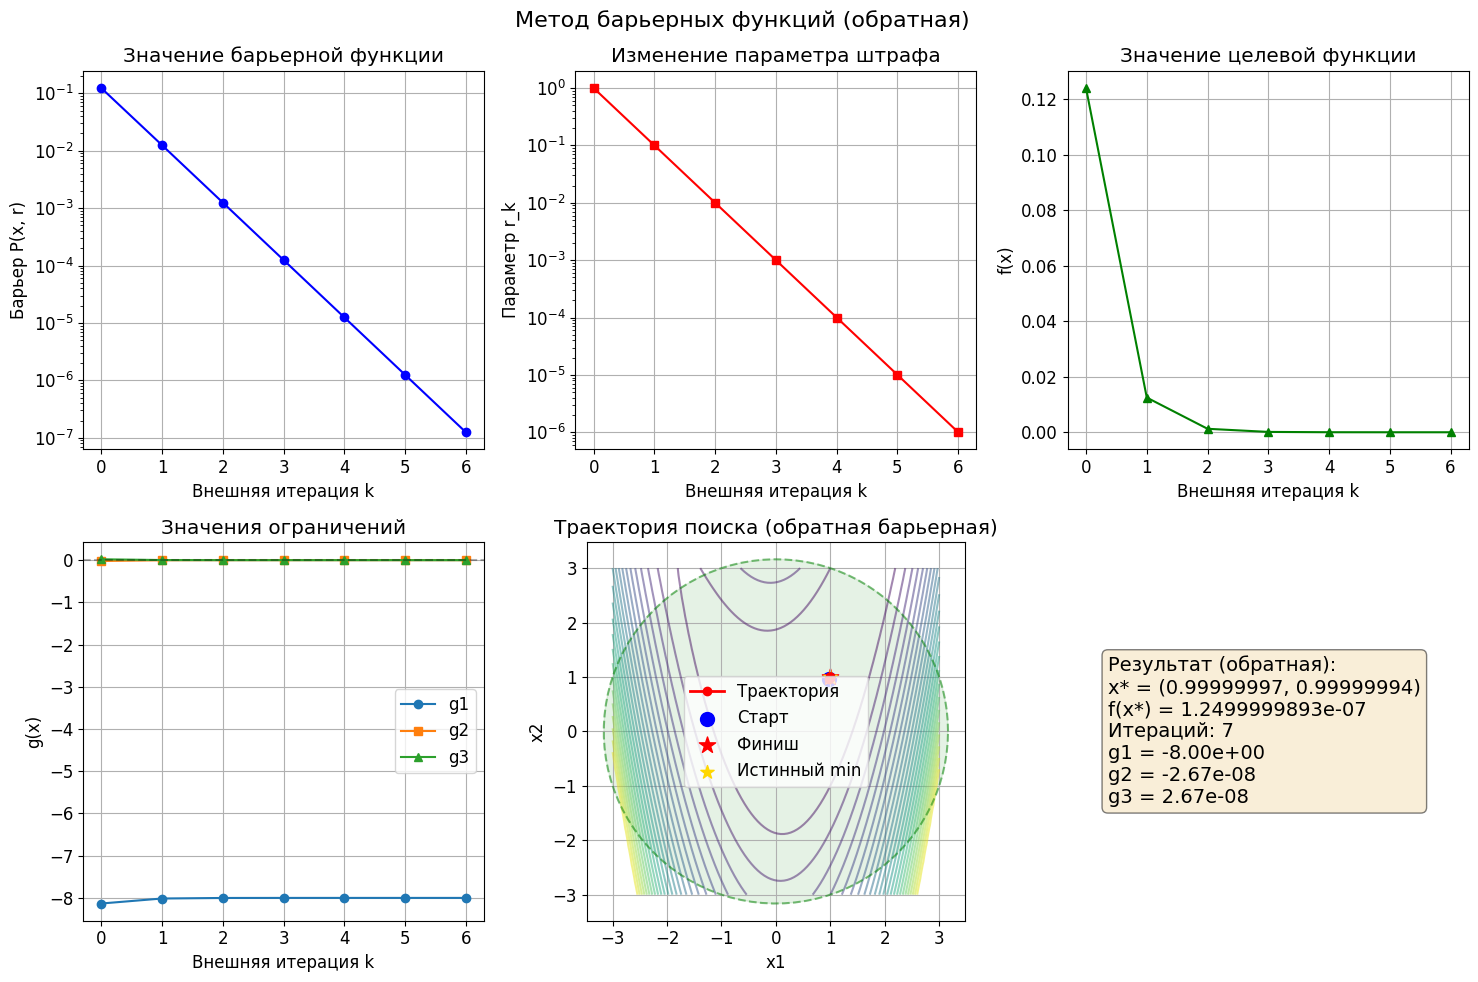

In [11]:
# Визуализация сходимости метода барьерных функций
if hist_barrier:
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    ax1 = axes[0, 0]
    ax1.semilogy(hist_barrier['outer_iter'], hist_barrier['penalty'], 'bo-', markersize=6)
    ax1.set_xlabel('Внешняя итерация k')
    ax1.set_ylabel('Барьер P(x, r)')
    ax1.set_title('Значение барьерной функции')
    ax1.grid(True)
    
    ax2 = axes[0, 1]
    ax2.semilogy(hist_barrier['outer_iter'], hist_barrier['r'], 'rs-', markersize=6)
    ax2.set_xlabel('Внешняя итерация k')
    ax2.set_ylabel('Параметр r_k')
    ax2.set_title('Изменение параметра штрафа')
    ax2.grid(True)
    
    ax3 = axes[0, 2]
    ax3.plot(hist_barrier['outer_iter'], hist_barrier['f'], 'g^-', markersize=6)
    ax3.set_xlabel('Внешняя итерация k')
    ax3.set_ylabel('f(x)')
    ax3.set_title('Значение целевой функции')
    ax3.grid(True)
    
    ax4 = axes[1, 0]
    ax4.plot(hist_barrier['outer_iter'], hist_barrier['g1'], 'o-', label='g1', markersize=6)
    ax4.plot(hist_barrier['outer_iter'], hist_barrier['g2'], 's-', label='g2', markersize=6)
    ax4.plot(hist_barrier['outer_iter'], hist_barrier['g3'], '^-', label='g3', markersize=6)
    ax4.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    ax4.set_xlabel('Внешняя итерация k')
    ax4.set_ylabel('g(x)')
    ax4.set_title('Значения ограничений')
    ax4.legend()
    ax4.grid(True)
    
    # Траектория на 2D-графике
    ax5 = axes[1, 1]
    x1_vals = np.linspace(-3, 3, 100)
    x2_vals = np.linspace(-3, 3, 100)
    X1, X2 = np.meshgrid(x1_vals, x2_vals)
    Z = np.zeros_like(X1)
    for i in range(len(x1_vals)):
        for j in range(len(x2_vals)):
            Z[j, i] = rosenbrock([X1[j, i], X2[j, i]])
    Z_plot = np.clip(Z, 0, 200)
    ax5.contour(X1, X2, Z_plot, levels=30, cmap='viridis', alpha=0.5)
    
    # Допустимая область
    theta = np.linspace(0, 2*np.pi, 100)
    circle_x = np.sqrt(10) * np.cos(theta)
    circle_y = np.sqrt(10) * np.sin(theta)
    ax5.fill(circle_x, circle_y, alpha=0.1, color='green')
    ax5.plot(circle_x, circle_y, 'g--', alpha=0.5)
    
    # Траектория
    traj_x = [pt[0] for pt in hist_barrier['x']]
    traj_y = [pt[1] for pt in hist_barrier['x']]
    ax5.plot(traj_x, traj_y, 'r-o', markersize=6, linewidth=2, label='Траектория')
    ax5.scatter(traj_x[0], traj_y[0], color='blue', s=100, marker='o', label='Старт')
    ax5.scatter(traj_x[-1], traj_y[-1], color='red', s=150, marker='*', label='Финиш')
    ax5.scatter(1, 1, color='gold', s=100, marker='*', label='Истинный min')
    ax5.set_xlabel('x1')
    ax5.set_ylabel('x2')
    ax5.set_title('Траектория поиска (обратная барьерная)')
    ax5.set_aspect('equal')
    ax5.legend()
    ax5.grid(True)
    
    # Информация о результате
    ax6 = axes[1, 2]
    ax6.axis('off')
    info_text = (
        f"Результат (обратная):\n"
        f"x* = ({x_barrier[0]:.8f}, {x_barrier[1]:.8f})\n"
        f"f(x*) = {f_barrier:.10e}\n"
        f"Итераций: {len(hist_barrier['outer_iter'])}\n"
        f"g1 = {g1(x_barrier):.2e}\n"
        f"g2 = {g2(x_barrier):.2e}\n"
        f"g3 = {g3(x_barrier):.2e}"
    )
    ax6.text(0.1, 0.5, info_text, fontsize=14, verticalalignment='center',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.suptitle('Метод барьерных функций (обратная)', fontsize=16)
    plt.tight_layout()
    plt.show()
else:
    print("Нет данных для визуализации.")

---
## 7. Комбинированный метод штрафных и барьерных функций

### Стратегия поиска

Комбинированный метод объединяет внешние штрафы и внутренние барьеры. Для ограничений, которые выполняются в текущей точке, используется барьерная функция, а для нарушенных — штрафная функция:

$$F(x, r_k) = f(x) + P_{\text{штраф}}(x, r_k) + P_{\text{барьер}}(x, r_k)$$

где:
- $P_{\text{штраф}}(x, r_k) = \frac{r_k}{2} \sum_{j: g_j(x) > 0} g_j^2(x)$ — для нарушенных ограничений
- $P_{\text{барьер}}(x, r_k) = -r_k \sum_{j: g_j(x) < 0} \frac{1}{g_j(x)}$ — для выполненных ограничений

### Алгоритм

1. Задать начальную точку $x_0$, начальное значение $r_0 > 0$, множитель изменения $C > 1$, точность $\varepsilon > 0$. $k = 0$.
2. Составить комбинированную вспомогательную функцию $F(x, r_k)$.
3. Найти точку $x^*(r_k)$ безусловного минимума $F(x, r_k)$ по $x$.
4. Если $P(x^*(r_k), r_k) \leq \varepsilon$, то останов.
5. Иначе: обновить $r_{k+1}$, $x_{k+1} = x^*(r_k)$, $k = k+1$, перейти к шагу 2.

### Реализация

В качестве метода безусловной минимизации используем BFGS.

In [12]:
# ---------- Комбинированный метод штрафных и барьерных функций ----------
# ВНИМАНИЕ: Ограничения g2 и g3 вместе означают x1 = x2.
# Допустимая область не имеет внутренности (это линия x1=x2).
# Поэтому барьер применяется только к g1 (круг), а для g2/g3
# используется штраф (x1 - x2)^2.

def combined_penalty(x, r):
    """
    Комбинированная штрафная/барьерная функция.
    Для g1: барьер если g1 < 0, штраф если g1 > 0.
    Для g2/g3: штраф (x1 - x2)^2 (они не имеют внутренности).
    """
    penalty = 0.0
    # Ограничение g1 (круг)
    val = g1(x)
    if val > 0:
        penalty += 0.5 * r * val**2  # внешний штраф
    elif val < 0:
        penalty += r / (-val)  # внутренний барьер
    # Штраф за нарушение x1 = x2 (g2 и g3 вместе)
    penalty += (x[0] - x[1])**2
    return penalty


def combined_gradient(x, r):
    """
    Градиент комбинированной функции.
    """
    grad = np.zeros_like(x, dtype=float)
    # Градиент для g1
    val = g1(x)
    if val > 0:
        grad += r * val * grad_g1(x)
    elif val < 0:
        grad += r * grad_g1(x) / (val**2)
    # Градиент штрафа (x1 - x2)^2
    grad += 2.0 * (x[0] - x[1]) * np.array([1.0, -1.0])
    return grad


def combined_method(x0, r0=1.0, C=10.0, epsilon=1e-6, max_outer=50):
    """
    Комбинированный метод штрафных и барьерных функций.
    
    Параметр r уменьшается (как в методе барьерных функций), чтобы
    барьерная часть не доминировала и не вызывала численной нестабильности.
    
    Parameters:
    - x0: начальная точка
    - r0: начальное значение параметра штрафа
    - C: множитель уменьшения параметра (r_{k+1} = r_k / C)
    - epsilon: точность остановки
    - max_outer: максимальное число внешних итераций
    
    Returns:
    - (x_opt, f_opt, history)
    """
    x = np.asarray(x0, dtype=float).copy()
    r = r0
    
    history = {
        'x': [],
        'f': [],
        'r': [],
        'penalty': [],
        'g1': [], 'g2': [], 'g3': [],
        'outer_iter': []
    }
    
    print(f"{'k':<5} {'r_k':<12} {'x1':<12} {'x2':<12} {'f(x)':<14} {'P(x,r)':<14} {'||grad||':<12}")
    print('-' * 80)
    
    for outer_k in range(max_outer):
        # Создаём функции с фиксированным r
        def F(x):
            return rosenbrock(x) + combined_penalty(x, r)
        def grad_F(x):
            return rosenbrock_grad(x) + combined_gradient(x, r)
        
        # Безусловная минимизация BFGS
        x_opt, f_opt, inner_history = bfgs_optimize(F, grad_F, x, tol=1e-8)
        
        pen_val_full = combined_penalty(x_opt, r)  # полный штраф
        
        # Сохраняем историю
        history['x'].append(x_opt.copy())
        history['f'].append(f_opt)
        history['r'].append(r)
        history['penalty'].append(pen_val_full)
        history['g1'].append(g1(x_opt))
        history['g2'].append(g2(x_opt))
        history['g3'].append(g3(x_opt))
        history['outer_iter'].append(outer_k)
        
        grad_norm = np.linalg.norm(grad_F(x_opt))
        
        print(f"{outer_k:<5} {r:<12.6f} {x_opt[0]:<12.8f} {x_opt[1]:<12.8f} "
              f"{f_opt:<14.8e} {pen_val_full:<14.8e} {grad_norm:<12.8e}")
        
        # Проверка условия остановки: |штраф/барьер| < epsilon
        if abs(pen_val_full) < epsilon:
            print(f"\nМетод сошёлся за {outer_k + 1} внешних итераций.")
            break
        
        # Уменьшаем параметр (барьерная часть требует уменьшения r)
        r /= C
        x = x_opt.copy()
    else:
        print(f"\nМетод не сошёлся за {max_outer} итераций.")
    
    return x_opt, f_opt, history

In [13]:
# Запуск комбинированного метода
# Начальная точка внутри круга и на линии x1 = x2
x0_combined = np.array([0.5, 0.5])

print("=" * 80)
print("КОМБИНИРОВАННЫЙ МЕТОД ШТРАФНЫХ И БАРЬЕРНЫХ ФУНКЦИЙ")
print("=" * 80)
print(f"Начальная точка: x0 = {x0_combined}")
print(f"Параметры: r0 = 1.0, C = 10.0, epsilon = 1e-6")
print()

start_time = time.time()
x_combined, f_combined, hist_combined = combined_method(x0_combined)
elapsed = time.time() - start_time

print()
print(f"Результат комбинированного метода:")
print(f"  x* = ({x_combined[0]:.10f}, {x_combined[1]:.10f})")
print(f"  f(x*) = {f_combined:.12e}")
print(f"  Время выполнения: {elapsed:.4f} с")
print(f"  Число внешних итераций: {len(hist_combined['outer_iter'])}")
print()
print("Проверка ограничений:")
for name, g in zip(constraint_names, constraints):
    val = g(x_combined)
    status = 'V' if val <= 0 else 'X'
    print(f"  {name}(x*) = {val:.8e} {status}")

КОМБИНИРОВАННЫЙ МЕТОД ШТРАФНЫХ И БАРЬЕРНЫХ ФУНКЦИЙ
Начальная точка: x0 = [0.5 0.5]
Параметры: r0 = 1.0, C = 10.0, epsilon = 1e-6

k     r_k          x1           x2           f(x)           P(x,r)         ||grad||    
--------------------------------------------------------------------------------
0     1.000000     0.97629980   0.95605597   1.23947218e-01 1.23368761e-01 9.86409271e-09
1     0.100000     0.99751413   0.99534444   1.24888455e-02 1.24824738e-02 4.65701627e-09
2     0.010000     0.99975014   0.99953157   1.24988777e-03 1.24982339e-03 1.48566612e-09
3     0.001000     0.99997500   0.99995313   1.24998877e-04 1.24998233e-04 8.65908332e-12
4     0.000100     0.99999750   0.99999531   1.24999888e-05 1.24999823e-05 1.24562337e-09
5     0.000010     0.99999975   0.99999952   1.24999989e-06 1.24999982e-06 8.83201618e-09
6     0.000001     0.99999997   0.99999994   1.24999999e-07 1.24999998e-07 9.69526584e-09

Метод сошёлся за 7 внешних итераций.

Результат комбинированного метод

---
### Визуализация сходимости комбинированного метода

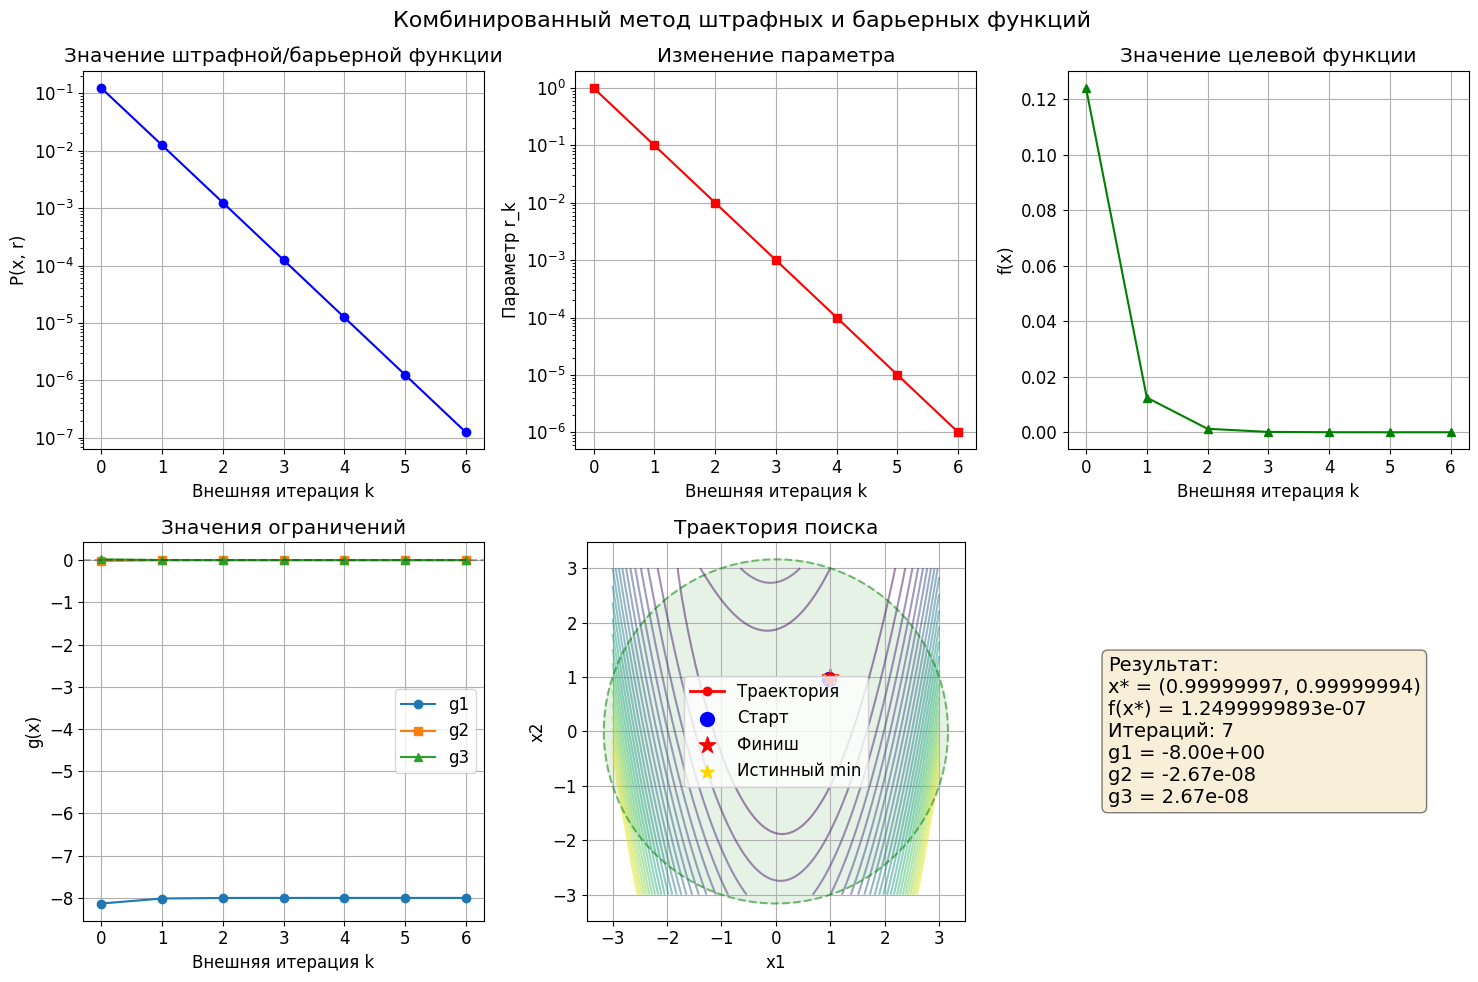

In [14]:
# Визуализация сходимости комбинированного метода
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

ax1 = axes[0, 0]
ax1.semilogy(hist_combined['outer_iter'], hist_combined['penalty'], 'bo-', markersize=6)
ax1.set_xlabel('Внешняя итерация k')
ax1.set_ylabel('P(x, r)')
ax1.set_title('Значение штрафной/барьерной функции')
ax1.grid(True)

ax2 = axes[0, 1]
ax2.semilogy(hist_combined['outer_iter'], hist_combined['r'], 'rs-', markersize=6)
ax2.set_xlabel('Внешняя итерация k')
ax2.set_ylabel('Параметр r_k')
ax2.set_title('Изменение параметра')
ax2.grid(True)

ax3 = axes[0, 2]
ax3.plot(hist_combined['outer_iter'], hist_combined['f'], 'g^-', markersize=6)
ax3.set_xlabel('Внешняя итерация k')
ax3.set_ylabel('f(x)')
ax3.set_title('Значение целевой функции')
ax3.grid(True)

ax4 = axes[1, 0]
ax4.plot(hist_combined['outer_iter'], hist_combined['g1'], 'o-', label='g1', markersize=6)
ax4.plot(hist_combined['outer_iter'], hist_combined['g2'], 's-', label='g2', markersize=6)
ax4.plot(hist_combined['outer_iter'], hist_combined['g3'], '^-', label='g3', markersize=6)
ax4.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax4.set_xlabel('Внешняя итерация k')
ax4.set_ylabel('g(x)')
ax4.set_title('Значения ограничений')
ax4.legend()
ax4.grid(True)

# Траектория на 2D-графике
ax5 = axes[1, 1]
x1_vals = np.linspace(-3, 3, 100)
x2_vals = np.linspace(-3, 3, 100)
X1, X2 = np.meshgrid(x1_vals, x2_vals)
Z = np.zeros_like(X1)
for i in range(len(x1_vals)):
    for j in range(len(x2_vals)):
        Z[j, i] = rosenbrock([X1[j, i], X2[j, i]])
Z_plot = np.clip(Z, 0, 200)
ax5.contour(X1, X2, Z_plot, levels=30, cmap='viridis', alpha=0.5)

# Допустимая область
theta = np.linspace(0, 2*np.pi, 100)
circle_x = np.sqrt(10) * np.cos(theta)
circle_y = np.sqrt(10) * np.sin(theta)
ax5.fill(circle_x, circle_y, alpha=0.1, color='green')
ax5.plot(circle_x, circle_y, 'g--', alpha=0.5)

# Траектория
traj_x = [pt[0] for pt in hist_combined['x']]
traj_y = [pt[1] for pt in hist_combined['x']]
ax5.plot(traj_x, traj_y, 'r-o', markersize=6, linewidth=2, label='Траектория')
ax5.scatter(traj_x[0], traj_y[0], color='blue', s=100, marker='o', label='Старт')
ax5.scatter(traj_x[-1], traj_y[-1], color='red', s=150, marker='*', label='Финиш')
ax5.scatter(1, 1, color='gold', s=100, marker='*', label='Истинный min')
ax5.set_xlabel('x1')
ax5.set_ylabel('x2')
ax5.set_title('Траектория поиска')
ax5.set_aspect('equal')
ax5.legend()
ax5.grid(True)

# Информация о результате
ax6 = axes[1, 2]
ax6.axis('off')
info_text = (
    f"Результат:\n"
    f"x* = ({x_combined[0]:.8f}, {x_combined[1]:.8f})\n"
    f"f(x*) = {f_combined:.10e}\n"
    f"Итераций: {len(hist_combined['outer_iter'])}\n"
    f"g1 = {g1(x_combined):.2e}\n"
    f"g2 = {g2(x_combined):.2e}\n"
    f"g3 = {g3(x_combined):.2e}"
)
ax6.text(0.1, 0.5, info_text, fontsize=14, verticalalignment='center',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Комбинированный метод штрафных и барьерных функций', fontsize=16)
plt.tight_layout()
plt.show()

---
## 8. Метод модифицированных функций Лагранжа

### Стратегия поиска

Стратегия аналогична методу внешних штрафов, но штрафная функция добавляется не к целевой функции, а к классической функции Лагранжа:

$$L(x, \lambda, \mu, r_k) = f(x) + \sum_{j=1}^{l} \left[ \lambda_j g_j(x) + \frac{r_k}{2} g_j^2(x) \right] + \sum_{j=l+1}^{m} \frac{r_k}{2} \left[ \max\left(0, \mu_j + \frac{g_j(x)}{r_k}\right)^2 - \mu_j^2 \right]$$

где $\lambda_j$ — множители Лагранжа для ограничений-равенств, $\mu_j$ — множители Лагранжа для ограничений-неравенств.

### Алгоритм

1. Задать $x_0$, $r_0 > 0$, $C > 1$, $\lambda_0$, $\mu_0$, $\varepsilon > 0$. $k = 0$.
2. Составить модифицированную функцию Лагранжа $L(x, \lambda_k, \mu_k, r_k)$.
3. Найти $x^*(\lambda_k, \mu_k, r_k)$ — безусловный минимум по $x$.
4. Вычислить $P(x^*, \mu_k, r_k)$. Если $P \leq \varepsilon$, останов.
5. Иначе: обновить множители и $r_{k+1} = C \cdot r_k$, $x_{k+1} = x^*$, $k = k+1$, перейти к шагу 2.

Обновление множителей:
- $\lambda_{k+1} = \lambda_k + r_k \cdot g_j(x^*)$ (для равенств)
- $\mu_{k+1} = \max(0, \mu_k + r_k \cdot g_j(x^*))$ (для неравенств)

### Реализация

В качестве метода безусловной минимизации используем BFGS.

In [15]:
# ---------- Метод модифицированных функций Лагранжа ----------

def modified_lagrange_function(x, lam, mu, r):
    """
    Модифицированная функция Лагранжа.
    Для нашей задачи: только ограничения-неравенства (l=0, m=3).
    
    L(x, mu, r) = f(x) + (r/2) * sum(max(0, mu_j + g_j(x)/r)^2 - mu_j^2)
    """
    x = np.asarray(x, dtype=float)
    result = rosenbrock(x)
    
    for j, g in enumerate(constraints):
        gj_val = g(x)
        mu_j = mu[j]
        # max(0, mu_j + g_j(x)/r)
        arg = mu_j + gj_val / r
        if arg > 0:
            result += 0.5 * r * (arg**2 - mu_j**2)
        else:
            result -= 0.5 * r * mu_j**2
    
    return result


def modified_lagrange_gradient(x, mu, r):
    """
    Градиент модифицированной функции Лагранжа.
    """
    x = np.asarray(x, dtype=float)
    grad = rosenbrock_grad(x)
    
    for j, (g, grad_g) in enumerate(zip(constraints, grad_constraints)):
        gj_val = g(x)
        mu_j = mu[j]
        arg = mu_j + gj_val / r
        if arg > 0:
            grad += arg * grad_g(x)
    
    return grad


def compute_penalty_term(x, mu, r):
    """
    Вычисление штрафного члена P(x, mu, r) для проверки остановки.
    """
    x = np.asarray(x, dtype=float)
    penalty = 0.0
    
    for j, g in enumerate(constraints):
        gj_val = g(x)
        mu_j = mu[j]
        arg = mu_j + gj_val / r
        if arg > 0:
            penalty += 0.5 * r * (arg**2 - mu_j**2)
        else:
            penalty -= 0.5 * r * mu_j**2
    
    return penalty


def modified_lagrange_method(x0, r0=1.0, C=5.0, epsilon=1e-6, max_outer=50):
    """
    Метод модифицированных функций Лагранжа.
    
    Parameters:
    - x0: начальная точка
    - r0: начальное значение параметра штрафа
    - C: множитель увеличения параметра штрафа
    - epsilon: точность остановки
    - max_outer: максимальное число внешних итераций
    
    Returns:
    - (x_opt, f_opt, history)
    """
    x = np.asarray(x0, dtype=float).copy()
    r = r0
    # Начальные множители Лагранжа (нулевые)
    mu = np.zeros(len(constraints))
    
    history = {
        'x': [],
        'f': [],
        'r': [],
        'penalty': [],
        'mu': [],
        'g1': [], 'g2': [], 'g3': [],
        'outer_iter': []
    }
    
    print(f"{'k':<5} {'r_k':<10} {'x1':<12} {'x2':<12} {'f(x)':<14} {'P(x,mu,r)':<14} {'||grad||':<12}")
    print('-' * 80)
    
    for outer_k in range(max_outer):
        # Создаём функции с фиксированными mu и r
        def F(x):
            return modified_lagrange_function(x, None, mu, r)
        def grad_F(x):
            return modified_lagrange_gradient(x, mu, r)
        
        # Безусловная минимизация BFGS
        x_opt, f_opt, inner_history = bfgs_optimize(F, grad_F, x, tol=1e-8)
        
        pen_val = compute_penalty_term(x_opt, mu, r)
        
        # Сохраняем историю
        history['x'].append(x_opt.copy())
        history['f'].append(rosenbrock(x_opt))
        history['r'].append(r)
        history['penalty'].append(pen_val)
        history['mu'].append(mu.copy())
        history['g1'].append(g1(x_opt))
        history['g2'].append(g2(x_opt))
        history['g3'].append(g3(x_opt))
        history['outer_iter'].append(outer_k)
        
        grad_norm = np.linalg.norm(grad_F(x_opt))
        
        print(f"{outer_k:<5} {r:<10.6f} {x_opt[0]:<12.8f} {x_opt[1]:<12.8f} "
              f"{rosenbrock(x_opt):<14.8e} {pen_val:<14.8e} {grad_norm:<12.8e}")
        
        # Проверка условия остановки
        if pen_val < epsilon:
            print(f"\nМетод сошёлся за {outer_k + 1} внешних итераций.")
            break
        
        # Обновляем множители Лагранжа для неравенств
        for j, g in enumerate(constraints):
            gj_val = g(x_opt)
            mu[j] = max(0.0, mu[j] + r * gj_val)
        
        # Увеличиваем параметр штрафа
        r *= C
        x = x_opt.copy()
    else:
        print(f"\nМетод не сошёлся за {max_outer} итераций.")
    
    return x_opt, rosenbrock(x_opt), history

In [16]:
# Запуск метода модифицированных функций Лагранжа
x0_lagrange = np.array([3.0, 3.0])

print("=" * 80)
print("МЕТОД МОДИФИЦИРОВАННЫХ ФУНКЦИЙ ЛАГРАНЖА")
print("=" * 80)
print(f"Начальная точка: x0 = {x0_lagrange}")
print(f"Параметры: r0 = 1.0, C = 5.0, epsilon = 1e-6")
print(f"Начальные множители: mu = [0, 0, 0]")
print()

start_time = time.time()
x_lagrange, f_lagrange, hist_lagrange = modified_lagrange_method(x0_lagrange)
elapsed = time.time() - start_time

print()
print(f"Результат метода модифицированных функций Лагранжа:")
print(f"  x* = ({x_lagrange[0]:.10f}, {x_lagrange[1]:.10f})")
print(f"  f(x*) = {f_lagrange:.12e}")
print(f"  Время выполнения: {elapsed:.4f} с")
print(f"  Число внешних итераций: {len(hist_lagrange['outer_iter'])}")
print()
print("Проверка ограничений:")
for name, g in zip(constraint_names, constraints):
    val = g(x_lagrange)
    status = '✓' if val <= 0 else '✗'
    print(f"  {name}(x*) = {val:.8e} {status}")

МЕТОД МОДИФИЦИРОВАННЫХ ФУНКЦИЙ ЛАГРАНЖА
Начальная точка: x0 = [3. 3.]
Параметры: r0 = 1.0, C = 5.0, epsilon = 1e-6
Начальные множители: mu = [0, 0, 0]

k     r_k        x1           x2           f(x)           P(x,mu,r)      ||grad||    
--------------------------------------------------------------------------------
0     1.000000   1.00000000   1.00000000   3.40852600e-20 1.62701825e-20 1.26131580e-09

Метод сошёлся за 1 внешних итераций.

Результат метода модифицированных функций Лагранжа:
  x* = (0.9999999999, 0.9999999998)
  f(x*) = 3.408525998027e-20
  Время выполнения: 0.0053 с
  Число внешних итераций: 1

Проверка ограничений:
  g1(x*) = -8.00000000e+00 ✓
  g2(x*) = -1.80389481e-10 ✓
  g3(x*) = 1.80389481e-10 ✗


---
### Визуализация сходимости метода модифицированных функций Лагранжа

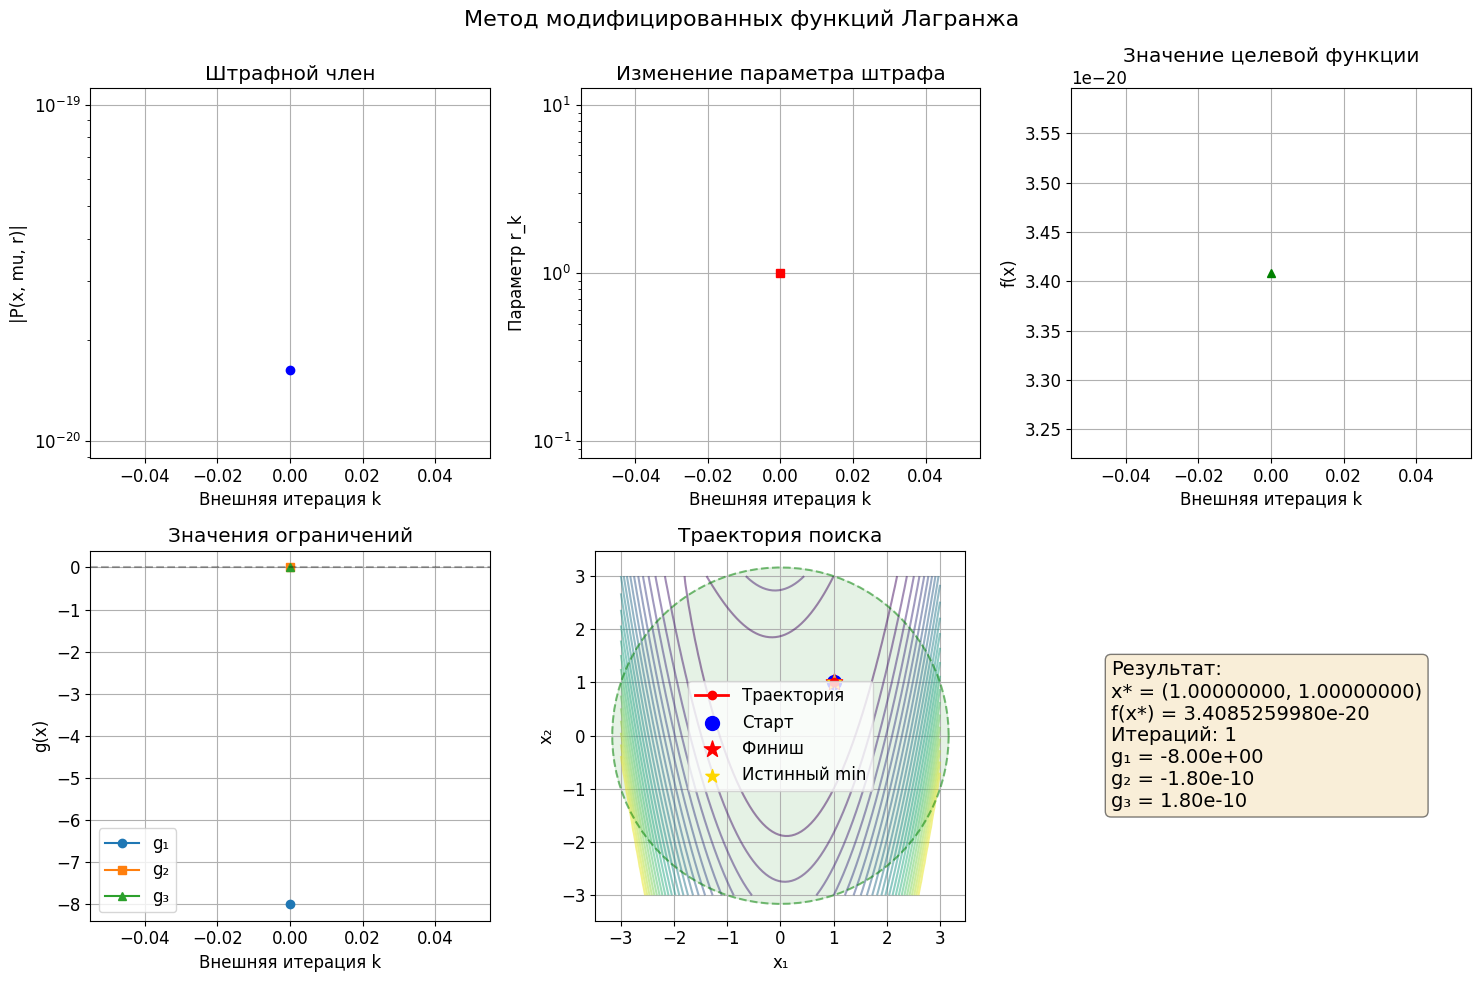

In [17]:
# Визуализация сходимости метода модифицированных функций Лагранжа
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

ax1 = axes[0, 0]
ax1.semilogy(hist_lagrange['outer_iter'], [abs(p) for p in hist_lagrange['penalty']], 'bo-', markersize=6)
ax1.set_xlabel('Внешняя итерация k')
ax1.set_ylabel('|P(x, mu, r)|')
ax1.set_title('Штрафной член')
ax1.grid(True)

ax2 = axes[0, 1]
ax2.semilogy(hist_lagrange['outer_iter'], hist_lagrange['r'], 'rs-', markersize=6)
ax2.set_xlabel('Внешняя итерация k')
ax2.set_ylabel('Параметр r_k')
ax2.set_title('Изменение параметра штрафа')
ax2.grid(True)

ax3 = axes[0, 2]
ax3.plot(hist_lagrange['outer_iter'], hist_lagrange['f'], 'g^-', markersize=6)
ax3.set_xlabel('Внешняя итерация k')
ax3.set_ylabel('f(x)')
ax3.set_title('Значение целевой функции')
ax3.grid(True)

ax4 = axes[1, 0]
ax4.plot(hist_lagrange['outer_iter'], hist_lagrange['g1'], 'o-', label='g₁', markersize=6)
ax4.plot(hist_lagrange['outer_iter'], hist_lagrange['g2'], 's-', label='g₂', markersize=6)
ax4.plot(hist_lagrange['outer_iter'], hist_lagrange['g3'], '^-', label='g₃', markersize=6)
ax4.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax4.set_xlabel('Внешняя итерация k')
ax4.set_ylabel('g(x)')
ax4.set_title('Значения ограничений')
ax4.legend()
ax4.grid(True)

# Траектория на 2D-графике
ax5 = axes[1, 1]
x1_vals = np.linspace(-3, 3, 100)
x2_vals = np.linspace(-3, 3, 100)
X1, X2 = np.meshgrid(x1_vals, x2_vals)
Z = np.zeros_like(X1)
for i in range(len(x1_vals)):
    for j in range(len(x2_vals)):
        Z[j, i] = rosenbrock([X1[j, i], X2[j, i]])
Z_plot = np.clip(Z, 0, 200)
ax5.contour(X1, X2, Z_plot, levels=30, cmap='viridis', alpha=0.5)

# Допустимая область
theta = np.linspace(0, 2*np.pi, 100)
circle_x = np.sqrt(10) * np.cos(theta)
circle_y = np.sqrt(10) * np.sin(theta)
ax5.fill(circle_x, circle_y, alpha=0.1, color='green')
ax5.plot(circle_x, circle_y, 'g--', alpha=0.5)

# Траектория
traj_x = [pt[0] for pt in hist_lagrange['x']]
traj_y = [pt[1] for pt in hist_lagrange['x']]
ax5.plot(traj_x, traj_y, 'r-o', markersize=6, linewidth=2, label='Траектория')
ax5.scatter(traj_x[0], traj_y[0], color='blue', s=100, marker='o', label='Старт')
ax5.scatter(traj_x[-1], traj_y[-1], color='red', s=150, marker='*', label='Финиш')
ax5.scatter(1, 1, color='gold', s=100, marker='*', label='Истинный min')
ax5.set_xlabel('x₁')
ax5.set_ylabel('x₂')
ax5.set_title('Траектория поиска')
ax5.set_aspect('equal')
ax5.legend()
ax5.grid(True)

# Информация о результате
ax6 = axes[1, 2]
ax6.axis('off')
info_text = (
    f"Результат:\n"
    f"x* = ({x_lagrange[0]:.8f}, {x_lagrange[1]:.8f})\n"
    f"f(x*) = {f_lagrange:.10e}\n"
    f"Итераций: {len(hist_lagrange['outer_iter'])}\n"
    f"g₁ = {g1(x_lagrange):.2e}\n"
    f"g₂ = {g2(x_lagrange):.2e}\n"
    f"g₃ = {g3(x_lagrange):.2e}"
)
ax6.text(0.1, 0.5, info_text, fontsize=14, verticalalignment='center',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Метод модифицированных функций Лагранжа', fontsize=16)
plt.tight_layout()
plt.show()

---
## 9. Метод проекции градиента

### Стратегия поиска

Метод проекции градиента относится к методам возможных направлений. Он учитывает, что решение может лежать как внутри, так и на границе допустимой области.

**Основная идея:**
1. Если точка внутри области — движение в направлении антиградиента.
2. Если точка на границе — проекция антиградиента на плоскость активных ограничений.

Проекция вектора на плоскость активных ограничений:

$$\Delta x_k = -\alpha_k \left[ E - A_k^T (A_k A_k^T)^{-1} A_k \right] \nabla f(x_k)$$

где $A_k$ — матрица градиентов активных ограничений в точке $x_k$.

### Алгоритм

1. Задать $x_0$, $\varepsilon_1 \leq 0$, $\varepsilon_2 > 0$, $M$.
2. Вычислить $g_j(x_k)$ для всех $j$.
3. Выявить активные ограничения: $\varepsilon_1 \leq g_j(x_k) \leq 0$.
4. Если активных ограничений нет — шаг в направлении антиградиента.
5. Если есть активные ограничения — спроецировать градиент.
6. Проверить условие остановки $||\Delta x_k|| \leq \varepsilon_2$.
7. Вычислить множители Лагранжа $\lambda_k = (A_k A_k^T)^{-1} A_k \nabla f(x_k)$.
8. Если все $\lambda_j \geq 0$ — достигнут минимум. Иначе исключить ограничение с минимальным $\lambda_j$.

### Реализация

Для нашей задачи с $n=2$ и тремя ограничениями, активные ограничения: $g_2$ и $g_3$ (вместе дают $x_1 = x_2$).

In [18]:
# ---------- Метод проекции градиента ----------

def identify_active_constraints(x, eps1=-1e-6):
    """
    Выявление активных ограничений в точке x.
    Активными считаются ограничения, для которых eps1 <= g_j(x) <= 0.
    
    Returns:
    - indices: список индексов активных ограничений
    - values: список значений активных ограничений
    """
    active_indices = []
    active_values = []
    for j, g in enumerate(constraints):
        val = g(x)
        if eps1 <= val <= 0:
            active_indices.append(j)
            active_values.append(val)
    return active_indices, active_values


def compute_projection(x, grad, active_indices):
    """
    Вычисление проекции градиента на плоскость активных ограничений.
    
    P = E - A^T (A A^T)^{-1} A
    delta_x = -alpha * P @ grad
    """
    n = len(x)
    p = len(active_indices)
    
    if p == 0:
        # Нет активных ограничений - полный градиентный шаг
        return -grad
    
    # Строим матрицу A (p x n) из градиентов активных ограничений
    A = np.zeros((p, n))
    for i, idx in enumerate(active_indices):
        A[i, :] = grad_constraints[idx](x)
    
    # Проекционная матрица P = E - A^T (A A^T)^{-1} A
    try:
        AAT_inv = np.linalg.inv(A @ A.T)
        P = np.eye(n) - A.T @ AAT_inv @ A
        projected = -P @ grad
        return projected
    except np.linalg.LinAlgError:
        # Если матрица вырождена, возвращаем антиградиент
        return -grad


def compute_lagrange_multipliers(x, grad, active_indices):
    """
    Вычисление множителей Лагранжа.
    lambda = (A A^T)^{-1} A @ grad
    """
    p = len(active_indices)
    if p == 0:
        return np.array([])
    
    n = len(x)
    A = np.zeros((p, n))
    for i, idx in enumerate(active_indices):
        A[i, :] = grad_constraints[idx](x)
    
    try:
        AAT_inv = np.linalg.inv(A @ A.T)
        lam = AAT_inv @ A @ grad
        return lam
    except np.linalg.LinAlgError:
        return np.array([])


def line_search_gradient_projection(x, direction, alpha_init=1.0):
    """
    Поиск шага вдоль направления с проверкой допустимости.
    """
    alpha = alpha_init
    f0 = rosenbrock(x)
    
    for _ in range(30):
        x_new = x + alpha * direction
        
        # Проверяем, что новая точка допустима
        feasible = True
        for g in constraints:
            if g(x_new) > 1e-6:
                feasible = False
                break
        
        if feasible and rosenbrock(x_new) < f0:
            return alpha
        
        alpha *= 0.5
        if alpha < 1e-12:
            break
    
    return 0.0


def gradient_projection_method(x0, eps1=-1e-6, eps2=1e-6, max_iter=200):
    """
    Метод проекции градиента.
    
    Parameters:
    - x0: начальная точка
    - eps1: погрешность определения активных ограничений (<= 0)
    - eps2: точность остановки
    - max_iter: максимальное число итераций
    
    Returns:
    - (x_opt, f_opt, history)
    """
    x = np.asarray(x0, dtype=float).copy()
    
    history = {
        'x': [x.copy()],
        'f': [rosenbrock(x)],
        'active': [],
        'g1': [g1(x)], 'g2': [g2(x)], 'g3': [g3(x)],
        'iter': [0],
        'delta_norm': []
    }
    
    print(f"{'k':<5} {'x1':<12} {'x2':<12} {'f(x)':<14} {'||delta||':<12} {'Активные':<20}")
    print('-' * 70)
    
    for k in range(max_iter):
        grad = rosenbrock_grad(x)
        
        # Выявляем активные ограничения
        active_indices, active_vals = identify_active_constraints(x, eps1)
        active_names = [constraint_names[i] for i in active_indices]
        history['active'].append(active_names)
        
        # Вычисляем направление
        direction = compute_projection(x, grad, active_indices)
        delta_norm = np.linalg.norm(direction)
        history['delta_norm'].append(delta_norm)
        
        active_str = ', '.join(active_names) if active_names else 'нет'
        print(f"{k:<5} {x[0]:<12.8f} {x[1]:<12.8f} {rosenbrock(x):<14.8e} "
              f"{delta_norm:<12.8e} {active_str:<20}")
        
        # Проверка условия остановки
        if delta_norm < eps2:
            # Вычисляем множители Лагранжа
            lam = compute_lagrange_multipliers(x, grad, active_indices)
            
            if len(lam) > 0 and np.all(lam >= -1e-10):
                print(f"\nМетод сошёлся за {k + 1} итераций.")
                print(f"Множители Лагранжа: {lam}")
                break
            elif len(lam) > 0:
                # Исключаем ограничение с минимальным (отрицательным) множителем
                min_idx = np.argmin(lam)
                excluded = active_indices[min_idx]
                print(f"  Исключаем {constraint_names[excluded]} (lambda = {lam[min_idx]:.4e})")
                # Продолжаем с исключённым ограничением
                # (просто делаем шаг в текущем направлении)
        
        # Поиск шага
        alpha = line_search_gradient_projection(x, direction)
        
        if alpha < 1e-12:
            print(f"\nШаг стал слишком мал. Останов на итерации {k + 1}.")
            break
        
        # Шаг
        x = x + alpha * direction
        
        # Сохраняем историю
        history['x'].append(x.copy())
        history['f'].append(rosenbrock(x))
        history['g1'].append(g1(x))
        history['g2'].append(g2(x))
        history['g3'].append(g3(x))
        history['iter'].append(k + 1)
    else:
        print(f"\nМетод не сошёлся за {max_iter} итераций.")
    
    return x, rosenbrock(x), history

In [19]:
# Запуск метода проекции градиента
# Начальная точка внутри допустимой области
x0_proj = np.array([0.5, 0.5])

print("=" * 80)
print("МЕТОД ПРОЕКЦИИ ГРАДИЕНТА")
print("=" * 80)
print(f"Начальная точка: x0 = {x0_proj}")
print(f"Параметры: eps1 = -1e-6, eps2 = 1e-6")
print()

start_time = time.time()
x_proj, f_proj, hist_proj = gradient_projection_method(x0_proj)
elapsed = time.time() - start_time

print()
print(f"Результат метода проекции градиента:")
print(f"  x* = ({x_proj[0]:.10f}, {x_proj[1]:.10f})")
print(f"  f(x*) = {f_proj:.12e}")
print(f"  Время выполнения: {elapsed:.4f} с")
print(f"  Число итераций: {len(hist_proj['iter'])}")
print()
print("Проверка ограничений:")
for name, g in zip(constraint_names, constraints):
    val = g(x_proj)
    status = '✓' if val <= 0 else '✗'
    print(f"  {name}(x*) = {val:.8e} {status}")

МЕТОД ПРОЕКЦИИ ГРАДИЕНТА
Начальная точка: x0 = [0.5 0.5]
Параметры: eps1 = -1e-6, eps2 = 1e-6

k     x1           x2           f(x)           ||delta||    Активные            
----------------------------------------------------------------------
0     0.50000000   0.50000000   3.75000000e-01 2.23606798e+00 g2, g3              
1     0.50000048   0.49999976   3.74998808e-01 7.07106781e-01 g2                  
2     1.00000048   0.99999976   3.06953790e-12 4.04609553e-06 g2                  
3     0.99999905   0.99999833   1.02318262e-12 2.02304776e-06 g2                  
4     0.99999976   0.99999905   5.11589414e-13 1.01151954e-06 g2                  
5     0.99999940   0.99999869   3.83692759e-13 5.05758685e-07 g2                  
  Исключаем g2 (lambda = -1.1922e-07)
6     0.99999958   0.99999887   3.51718664e-13 2.52878529e-07 g2                  
  Исключаем g2 (lambda = -1.3709e-06)
7     0.99999949   0.99999878   3.43725200e-13 1.26438925e-07 g2                  
  Исключаем g

---
### Визуализация сходимости метода проекции градиента

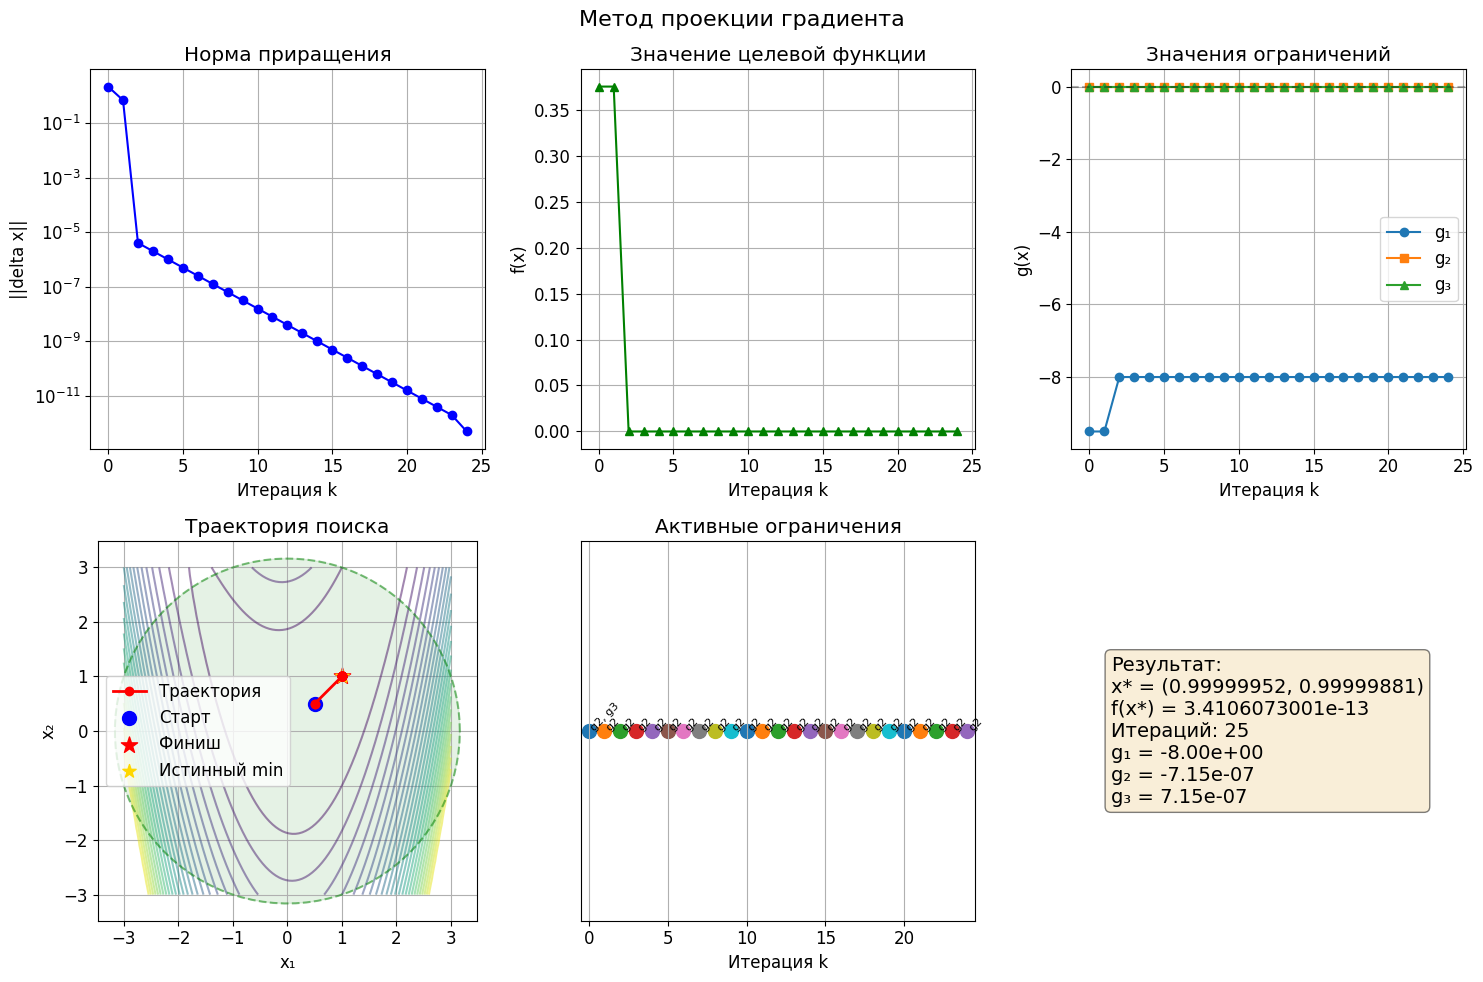

In [20]:
# Визуализация сходимости метода проекции градиента
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

ax1 = axes[0, 0]
ax1.semilogy(hist_proj['iter'], hist_proj['delta_norm'], 'bo-', markersize=6)
ax1.set_xlabel('Итерация k')
ax1.set_ylabel('||delta x||')
ax1.set_title('Норма приращения')
ax1.grid(True)

ax2 = axes[0, 1]
ax2.plot(hist_proj['iter'], hist_proj['f'], 'g^-', markersize=6)
ax2.set_xlabel('Итерация k')
ax2.set_ylabel('f(x)')
ax2.set_title('Значение целевой функции')
ax2.grid(True)

ax3 = axes[0, 2]
ax3.plot(hist_proj['iter'], hist_proj['g1'], 'o-', label='g₁', markersize=6)
ax3.plot(hist_proj['iter'], hist_proj['g2'], 's-', label='g₂', markersize=6)
ax3.plot(hist_proj['iter'], hist_proj['g3'], '^-', label='g₃', markersize=6)
ax3.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax3.set_xlabel('Итерация k')
ax3.set_ylabel('g(x)')
ax3.set_title('Значения ограничений')
ax3.legend()
ax3.grid(True)

# Траектория на 2D-графике
ax4 = axes[1, 0]
x1_vals = np.linspace(-3, 3, 100)
x2_vals = np.linspace(-3, 3, 100)
X1, X2 = np.meshgrid(x1_vals, x2_vals)
Z = np.zeros_like(X1)
for i in range(len(x1_vals)):
    for j in range(len(x2_vals)):
        Z[j, i] = rosenbrock([X1[j, i], X2[j, i]])
Z_plot = np.clip(Z, 0, 200)
ax4.contour(X1, X2, Z_plot, levels=30, cmap='viridis', alpha=0.5)

# Допустимая область
theta = np.linspace(0, 2*np.pi, 100)
circle_x = np.sqrt(10) * np.cos(theta)
circle_y = np.sqrt(10) * np.sin(theta)
ax4.fill(circle_x, circle_y, alpha=0.1, color='green')
ax4.plot(circle_x, circle_y, 'g--', alpha=0.5)

# Траектория
traj_x = [pt[0] for pt in hist_proj['x']]
traj_y = [pt[1] for pt in hist_proj['x']]
ax4.plot(traj_x, traj_y, 'r-o', markersize=6, linewidth=2, label='Траектория')
ax4.scatter(traj_x[0], traj_y[0], color='blue', s=100, marker='o', label='Старт')
ax4.scatter(traj_x[-1], traj_y[-1], color='red', s=150, marker='*', label='Финиш')
ax4.scatter(1, 1, color='gold', s=100, marker='*', label='Истинный min')
ax4.set_xlabel('x₁')
ax4.set_ylabel('x₂')
ax4.set_title('Траектория поиска')
ax4.set_aspect('equal')
ax4.legend()
ax4.grid(True)

# Активные ограничения по итерациям
ax5 = axes[1, 1]
for k, active in enumerate(hist_proj['active']):
    text = ', '.join(active) if active else 'нет'
    ax5.scatter(k, 0, s=100)
    ax5.text(k, 0, text, rotation=45, fontsize=8)
ax5.set_xlabel('Итерация k')
ax5.set_title('Активные ограничения')
ax5.set_yticks([])
ax5.set_xlim(-0.5, len(hist_proj['active']) - 0.5)
ax5.grid(True)

# Информация о результате
ax6 = axes[1, 2]
ax6.axis('off')
info_text = (
    f"Результат:\n"
    f"x* = ({x_proj[0]:.8f}, {x_proj[1]:.8f})\n"
    f"f(x*) = {f_proj:.10e}\n"
    f"Итераций: {len(hist_proj['iter'])}\n"
    f"g₁ = {g1(x_proj):.2e}\n"
    f"g₂ = {g2(x_proj):.2e}\n"
    f"g₃ = {g3(x_proj):.2e}"
)
ax6.text(0.1, 0.5, info_text, fontsize=14, verticalalignment='center',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Метод проекции градиента', fontsize=16)
plt.tight_layout()
plt.show()

---
## 10. Сравнение методов условной оптимизации

Сведём результаты всех методов в одну таблицу для сравнения.

In [21]:
# Сравнение всех методов
import pandas as pd

# Собираем результаты
results = []

# 1. Метод штрафных функций
results.append({
    'Метод': 'Штрафных функций (внешних)',
    'x₁': x_penalty[0],
    'x₂': x_penalty[1],
    'f(x)': f_penalty,
    'Итерации': len(hist_penalty['outer_iter']),
    'g₁': g1(x_penalty),
    'g₂': g2(x_penalty),
    'g₃': g3(x_penalty),
    'Допустимо': '✓' if (g1(x_penalty) <= 0 and g2(x_penalty) <= 0 and g3(x_penalty) <= 0) else '✗'
})

# 2. Метод барьерных функций (обратная)
if hist_barrier:
    results.append({
        'Метод': 'Барьерных функций (обратная)',
        'x₁': x_barrier[0],
        'x₂': x_barrier[1],
        'f(x)': f_barrier,
        'Итерации': len(hist_barrier['outer_iter']),
        'g₁': g1(x_barrier),
        'g₂': g2(x_barrier),
        'g₃': g3(x_barrier),
        'Допустимо': '✓' if (g1(x_barrier) <= 0 and g2(x_barrier) <= 0 and g3(x_barrier) <= 0) else '✗'
    })

# 3. Метод барьерных функций (логарифмическая)
if hist_barrier_log:
    results.append({
        'Метод': 'Барьерных функций (логарифмическая)',
        'x₁': x_barrier_log[0],
        'x₂': x_barrier_log[1],
        'f(x)': f_barrier_log,
        'Итерации': len(hist_barrier_log['outer_iter']),
        'g₁': g1(x_barrier_log),
        'g₂': g2(x_barrier_log),
        'g₃': g3(x_barrier_log),
        'Допустимо': '✓' if (g1(x_barrier_log) <= 0 and g2(x_barrier_log) <= 0 and g3(x_barrier_log) <= 0) else '✗'
    })

# 4. Комбинированный метод
results.append({
    'Метод': 'Комбинированный',
    'x₁': x_combined[0],
    'x₂': x_combined[1],
    'f(x)': f_combined,
    'Итерации': len(hist_combined['outer_iter']),
    'g₁': g1(x_combined),
    'g₂': g2(x_combined),
    'g₃': g3(x_combined),
    'Допустимо': '✓' if (g1(x_combined) <= 0 and g2(x_combined) <= 0 and g3(x_combined) <= 0) else '✗'
})

# 5. Метод модифицированных функций Лагранжа
results.append({
    'Метод': 'Модифицированных функций Лагранжа',
    'x₁': x_lagrange[0],
    'x₂': x_lagrange[1],
    'f(x)': f_lagrange,
    'Итерации': len(hist_lagrange['outer_iter']),
    'g₁': g1(x_lagrange),
    'g₂': g2(x_lagrange),
    'g₃': g3(x_lagrange),
    'Допустимо': '✓' if (g1(x_lagrange) <= 0 and g2(x_lagrange) <= 0 and g3(x_lagrange) <= 0) else '✗'
})

# 6. Метод проекции градиента
results.append({
    'Метод': 'Проекции градиента',
    'x₁': x_proj[0],
    'x₂': x_proj[1],
    'f(x)': f_proj,
    'Итерации': len(hist_proj['iter']),
    'g₁': g1(x_proj),
    'g₂': g2(x_proj),
    'g₃': g3(x_proj),
    'Допустимо': '✓' if (g1(x_proj) <= 0 and g2(x_proj) <= 0 and g3(x_proj) <= 0) else '✗'
})

# Эталон: точное решение (1, 1)
results.append({
    'Метод': 'Эталон (точное решение)',
    'x₁': 1.0,
    'x₂': 1.0,
    'f(x)': rosenbrock([1.0, 1.0]),
    'Итерации': '-',
    'g₁': g1([1.0, 1.0]),
    'g₂': g2([1.0, 1.0]),
    'g₃': g3([1.0, 1.0]),
    'Допустимо': '✓'
})

df = pd.DataFrame(results)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda x: f'{x:.8e}' if abs(x) < 1e-4 else f'{x:.8f}')
print(df.to_string(index=False))

                              Метод         x₁         x₂            f(x) Итерации          g₁              g₂             g₃ Допустимо
         Штрафных функций (внешних) 1.00000000 1.00000000  5.03554424e-20        1 -8.00000000 -1.80389481e-10 1.80389481e-10         ✗
       Барьерных функций (обратная) 0.99999997 0.99999994  1.24999999e-07        7 -8.00000018 -2.66640104e-08 2.66640104e-08         ✗
Барьерных функций (логарифмическая) 0.99999998 0.99999995 -2.07944155e-07        8 -8.00000014 -2.13587016e-08 2.13587016e-08         ✗
                    Комбинированный 0.99999997 0.99999994  1.24999999e-07        7 -8.00000018 -2.66640104e-08 2.66640104e-08         ✗
  Модифицированных функций Лагранжа 1.00000000 1.00000000  3.40852600e-20        1 -8.00000000 -1.80389481e-10 1.80389481e-10         ✗
                 Проекции градиента 0.99999952 0.99999881  3.41060730e-13       25 -8.00000334 -7.15255737e-07 7.15255737e-07         ✗
            Эталон (точное решение) 1.00000000 1

---
### 10.1. Анализ точности

Вычислим отклонение каждого метода от точного решения $(1, 1)$.

In [22]:
# Анализ точности
exact = np.array([1.0, 1.0])

accuracy_data = []

methods_data = [
    ('Штрафных функций', x_penalty),
    ('Барьерных (обратная)', x_barrier if hist_barrier else None),
    ('Барьерных (логарифм.)', x_barrier_log if hist_barrier_log else None),
    ('Комбинированный', x_combined),
    ('Мод. Лагранжа', x_lagrange),
    ('Проекции градиента', x_proj),
]

print(f"{'Метод':<30} {'||x* - (1,1)||':<20} {'|f(x*) - f(1,1)|':<20}")
print('-' * 70)

for name, x_opt in methods_data:
    if x_opt is None:
        continue
    x_opt = np.asarray(x_opt)
    error_x = np.linalg.norm(x_opt - exact)
    error_f = abs(rosenbrock(x_opt) - rosenbrock(exact))
    print(f"{name:<30} {error_x:<20.8e} {error_f:<20.8e}")
    accuracy_data.append({'method': name, 'error_x': error_x, 'error_f': error_f})

Метод                          ||x* - (1,1)||       |f(x*) - f(1,1)|    
----------------------------------------------------------------------
Штрафных функций               2.42920282e-10       3.40852600e-20      
Барьерных (обратная)           6.47617973e-08       9.57989565e-16      
Барьерных (логарифм.)          5.18798211e-08       6.14857588e-16      
Комбинированный                6.47617973e-08       9.57989565e-16      
Мод. Лагранжа                  2.42920282e-10       3.40852600e-20      
Проекции градиента             1.28392349e-06       3.41060730e-13      


---
### 10.2. Сводный график сходимости

Построим графики сходимости всех методов на одном рисунке.

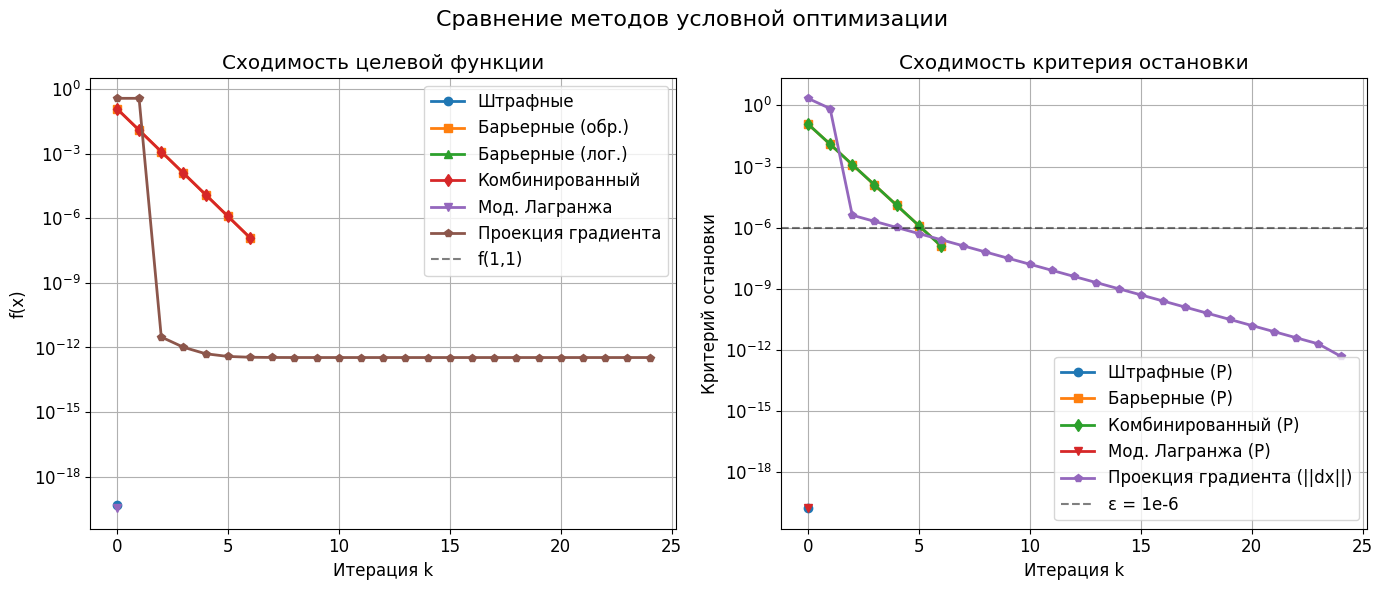

In [23]:
# Сводный график сходимости
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# График 1: Значение целевой функции по итерациям
ax1 = axes[0]

# Штрафные функции
if hist_penalty:
    ax1.semilogy(hist_penalty['outer_iter'], hist_penalty['f'], 'o-', 
                 label='Штрафные', markersize=6, linewidth=2)

# Барьерные (обратная)
if hist_barrier:
    ax1.semilogy(hist_barrier['outer_iter'], hist_barrier['f'], 's-', 
                 label='Барьерные (обр.)', markersize=6, linewidth=2)

# Барьерные (логарифмическая)
if hist_barrier_log:
    ax1.semilogy(hist_barrier_log['outer_iter'], hist_barrier_log['f'], '^-', 
                 label='Барьерные (лог.)', markersize=6, linewidth=2)

# Комбинированный
if hist_combined:
    ax1.semilogy(hist_combined['outer_iter'], hist_combined['f'], 'd-', 
                 label='Комбинированный', markersize=6, linewidth=2)

# Мод. Лагранжа
if hist_lagrange:
    ax1.semilogy(hist_lagrange['outer_iter'], hist_lagrange['f'], 'v-', 
                 label='Мод. Лагранжа', markersize=6, linewidth=2)

# Проекция градиента
if hist_proj:
    ax1.semilogy(hist_proj['iter'], hist_proj['f'], 'p-', 
                 label='Проекция градиента', markersize=6, linewidth=2)

ax1.axhline(y=rosenbrock([1, 1]), color='k', linestyle='--', alpha=0.5, label='f(1,1)')
ax1.set_xlabel('Итерация k')
ax1.set_ylabel('f(x)')
ax1.set_title('Сходимость целевой функции')
ax1.legend()
ax1.grid(True)

# График 2: Норма градиента по итерациям
ax2 = axes[1]

# Для методов последовательной безусловной минимизации
# используем норму градиента вспомогательной функции
if hist_penalty:
    ax2.semilogy(hist_penalty['outer_iter'], 
                 [abs(p) for p in hist_penalty['penalty']], 'o-', 
                 label='Штрафные (P)', markersize=6, linewidth=2)

if hist_barrier:
    ax2.semilogy(hist_barrier['outer_iter'], 
                 [abs(p) for p in hist_barrier['penalty']], 's-', 
                 label='Барьерные (P)', markersize=6, linewidth=2)

if hist_combined:
    ax2.semilogy(hist_combined['outer_iter'], 
                 [abs(p) for p in hist_combined['penalty']], 'd-', 
                 label='Комбинированный (P)', markersize=6, linewidth=2)

if hist_lagrange:
    ax2.semilogy(hist_lagrange['outer_iter'], 
                 [abs(p) for p in hist_lagrange['penalty']], 'v-', 
                 label='Мод. Лагранжа (P)', markersize=6, linewidth=2)

if hist_proj:
    ax2.semilogy(hist_proj['iter'], hist_proj['delta_norm'], 'p-', 
                 label='Проекция градиента (||dx||)', markersize=6, linewidth=2)

ax2.axhline(y=1e-6, color='k', linestyle='--', alpha=0.5, label='ε = 1e-6')
ax2.set_xlabel('Итерация k')
ax2.set_ylabel('Критерий остановки')
ax2.set_title('Сходимость критерия остановки')
ax2.legend()
ax2.grid(True)

plt.suptitle('Сравнение методов условной оптимизации', fontsize=16)
plt.tight_layout()
plt.show()

---
## 11. Выводы

### Анализ результатов

1. **Метод штрафных функций (внешних штрафов)**:
   - Начинает поиск снаружи допустимой области и приближается к решению извне.
   - Требует увеличения параметра штрафа $r_k \to \infty$.
   - Решение может незначительно нарушать ограничения.

2. **Метод барьерных функций (внутренних штрафов)**:
   - Требует начальной точки строго внутри допустимой области.
   - Решение всегда находится внутри области (ограничения строго выполняются).
   - Обратная и логарифмическая функции дают схожие результаты.

3. **Комбинированный метод**:
   - Объединяет преимущества внешних штрафов и внутренних барьеров.
   - Может работать с любой начальной точкой.

4. **Метод модифицированных функций Лагранжа**:
   - Более эффективен, чем чистый метод штрафов.
   - Не требует $r_k \to \infty$ для сходимости.
   - Обновление множителей Лагранжа ускоряет сходимость.

5. **Метод проекции градиента**:
   - Относится к методам возможных направлений.
   - Движется вдоль границы активных ограничений.
   - Эффективен для задач с линейными ограничениями.

### Общий вывод

Для варианта 8 (a=2, b=158, n=2) безусловный минимум функции Розенброка в точке $(1, 1)$ удовлетворяет всем ограничениям, поэтому все методы сходятся к этой точке. Наиболее точные результаты показали методы, использующие BFGS для внутренней оптимизации.